**Description of the Modules**

1. Imports: Import needed libraries
2. Final files:
*   Get gdf file from Google drive. To change the input file or folder change the names in the first cell
*   Create a dataset with the training data and reduce columns to include only columns *PREDICTION_FEATURES*. To add/delete columns, modify the set *PREDICTION_FEATURES*
3. Map categories: Maps categories in fynctype, computes correlations and creates enhanced features 1. To add/delete/change categories, modify *functype_to_english*
4. Prediction Models:

*   The first cell creates the features in three separate functions for each model *create_baseline_features, create_enhanced_features, create_enhanced_2_features* and runs the training. To add another feature in the any of the functions add the following code with the changed column name:
> if 'columns_name' in df.columns:
    features['columns_name'] = df['columns_name'].fillna('Unknown')
else:
    features['columns_name'] = 'Unknown'

*   Inference: Generation of the data. The final predictions are saved in **gdf_data['predicted_energy_demand']**

Note: Run all hidden cells in a together by collapsing the cells under each module and pressing run.



## Imports

In [ ]:
!pip install contextily geopandas matplotlib rasterio
!pip install tensorflow
# Run this in a notebook cell if XGBoost is missing:
!pip install xgboost

# Run this if TensorFlow is missing:
!pip install tensorflow

!pip install optuna

In [ ]:
import pandas as pd
import xgboost as xgb
import geopandas as gpd
import contextily as cx
import matplotlib.pyplot as plt
from shapely.geometry import box
import io
from PIL import Image
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder, QuantileTransformer, MinMaxScaler
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler

## Final files


In [ ]:
drive.mount('/content/drive')
folder_path_shared_final =  "/content/drive/MyDrive/GATE/Energy Consumption/Final_datasets/"
gdf_data = gpd.read_file(folder_path_shared_final + "buildings_SO_2025_enriched_shape_neighbour_energy_panels_nsiyear_18092025.geojson")
merged_data = gpd.read_file(folder_path_shared_final + "merged_energy_data_points_fixed_matching_kk_16092025.gpkg")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Get training dataset with 2100 buildings and essential columns for the prediction

In [ ]:
def create_overlapping_gdf_dataset(gdf_data, merged_data):
    # Define essential columns for prediction model
    PREDICTION_FEATURES = [
        # Energy demand columns (likely your target variables)
        'en2025_enegy_demand_present_m2', 'en2025_enegy_demand_after_m2',
        'en2025_enegy_demand_present_y', 'en2025_enegy_demand_after_y',
        'en2023_enegy_demand_present_m2', 'en2023_enegy_demand_after_m2',
        'en2023_enegy_demand_present_y', 'en2023_enegy_demand_after_y',

        # Building characteristics
        'en2025_area_heated_m2', 'en2025_vol_heated_m3', 'en2025_vol_cooled_m3',
        'en2025_gfa_m2', 'en2025_fp_area_m2', 'en2025_yearbuilt', 'en2025_type',
        'en2023_area_heated_m2', 'en2023_vol_heated_m3', 'en2023_vol_cooled_m3',
        'en2023_gfa_m2', 'en2023_fp_area_m2', 'en2023_yearbuilt', 'en2023_type',

        # Building classification and function
        'd_Category', 'c2025_funccode', 'c2025_functype', 'c2025_proptype',

        # Energy performance classes
        'en2025_class_present', 'en2025_class_after', 'en2025_epc_type',
        'en2023_class_present', 'en2023_class_after', 'en2023_epc_type',

        # Location information
        'en2025_mun', 'en2025_city', 'en2025_oblast',
        'en2023_mun', 'en2023_city', 'en2023_oblast',

        # Building structure
        'c2025_flrcount', 'en2023_floorcount', 'c2025_appcount',

        # Identification columns
        'en2025_cadnum', 'en2023_cadnum', 'c2025_cadnum',
        'en2025_name', 'en2023_name',

        # Address and location
        'en2025_addr', 'en2023_addr', 'c2025_immaddr',

        # Correlation columns (if they're calculated features)
        'd_Correlation_Energy_Demand', 'd_Correlation_Energy_Demand_ECM',
        'd_Correlation_Primary_Energy', 'd_Correlation_Primary_Energy_ECM',
        'd_Category'

        # Data quality indicator
        'd_Energy_Completeness_Pct',
        'geolocated'
    ]

    ADDITIONAL_GDF_COLUMNS = [
        '_address', 'col0', '_latitude', '_longitude', '_arcgis_longlabel',
        '_arcgis_exinfo', '_arcgis_wkid', 'fme_rejection_code', 'layer', 'path',
        'construction_type', 'id_new', 'nbuildingy', 'geometry', '_bldg_shape'
    ]

    # Step 1: Find common columns for overlap detection (same as before)
    common_cols = list(set(gdf_data.columns) & set(merged_data.columns))
    if 'geometry' in common_cols:
        common_cols.remove('geometry')

    print(f"Using {len(common_cols)} columns for overlap detection")
    print(f"Common columns: {common_cols[:10]}{'...' if len(common_cols) > 10 else ''}")

    # Keep only common columns from both datasets for overlap detection
    gdf_common_cols = gdf_data[common_cols].copy()
    merged_common_cols = merged_data[common_cols].copy()

    print(f"Original dataset sizes:")
    print(f"GDF data: {len(gdf_data):,} records with {len(gdf_data.columns)} total columns")
    print(f"Merged data: {len(merged_data):,} records")

    # Remove rows with all NaN values in common columns from both datasets
    gdf_clean = gdf_common_cols.dropna(how='all').copy()
    merged_clean = merged_common_cols.dropna(how='all').copy()

    print(f"\nAfter removing rows with all NaN in common columns:")
    print(f"GDF data: {len(gdf_clean):,} records")
    print(f"Merged data: {len(merged_clean):,} records")

    # Step 2: Get the overlapping row indices
    overlapping_indices = gdf_clean.index

    print(f"\nThese {len(overlapping_indices):,} records are the overlapping records!")

    # Step 3: Now filter to only essential columns
    # Combine prediction features and additional GDF columns
    desired_columns = PREDICTION_FEATURES + ADDITIONAL_GDF_COLUMNS

    # Find which desired columns actually exist in gdf_data
    available_columns = [col for col in desired_columns if col in gdf_data.columns]
    missing_columns = [col for col in desired_columns if col not in gdf_data.columns]

    print(f"\nColumn filtering:")
    print(f"Desired columns: {len(desired_columns)}")
    print(f"Available in gdf_data: {len(available_columns)}")
    if missing_columns:
        print(f"Missing columns: {missing_columns}")

    # Create final dataset with only overlapping rows and essential columns
    overlapping_gdf = gdf_data.loc[overlapping_indices, available_columns].copy()

    print(f"\nReturning overlapping dataset with essential columns only.")

    return overlapping_gdf, available_columns, missing_columns

# Execute the function
print("=== CREATING OVERLAPPING GDF DATASET WITH ESSENTIAL COLUMNS ===\n")

# Create the overlapping dataset
overlapping_gdf_dataset, selected_columns, missing_cols = create_overlapping_gdf_dataset(gdf_data, merged_data)

# Display basic info about the result
print(f"\nFinal dataset info:")
print(f"Shape: {overlapping_gdf_dataset.shape}")
print(f"Selected columns ({len(selected_columns)}): {selected_columns}")

print(f"\: Created overlapping dataset with {len(overlapping_gdf_dataset):,} records and {len(overlapping_gdf_dataset.columns)} columns")

=== CREATING OVERLAPPING GDF DATASET WITH ESSENTIAL COLUMNS ===

Using 91 columns for overlap detection
Common columns: ['c2025_proptype', 'en2025_class_present', 'en2023_fp_area_m2', 'en2025_addr', 'd_Correlation_Energy_Demand', 'en2025_epc_num', 'd_Correlation_Primary_Energy_ECM', 'en2025_fp_area_m2', 'd_Energy_Completeness_Pct', 'en2023_enegy_demand_after_y']...
Original dataset sizes:
GDF data: 266,368 records with 124 total columns
Merged data: 2,256 records

After removing rows with all NaN in common columns:
GDF data: 2,010 records
Merged data: 2,256 records

These 2,010 records are the overlapping records!

Column filtering:
Desired columns: 70
Available in gdf_data: 69
Missing columns: ['d_Categoryd_Energy_Completeness_Pct']

Returning overlapping dataset with essential columns only.

Final dataset info:
Shape: (2010, 69)
Selected columns (69): ['en2025_enegy_demand_present_m2', 'en2025_enegy_demand_after_m2', 'en2025_enegy_demand_present_y', 'en2025_enegy_demand_after_y', 'en

In [ ]:
overlapping_gdf_dataset["d_Category"]

,d_Category
237943,Shops
237944,Shops
237945,Shops
237946,Administrative Buildings
237947,Administrative Buildings
...,...
240507,Educational Buildings
240508,Administrative Buildings
240509,Administrative Buildings
240510,Residential Buildings - Multi-family


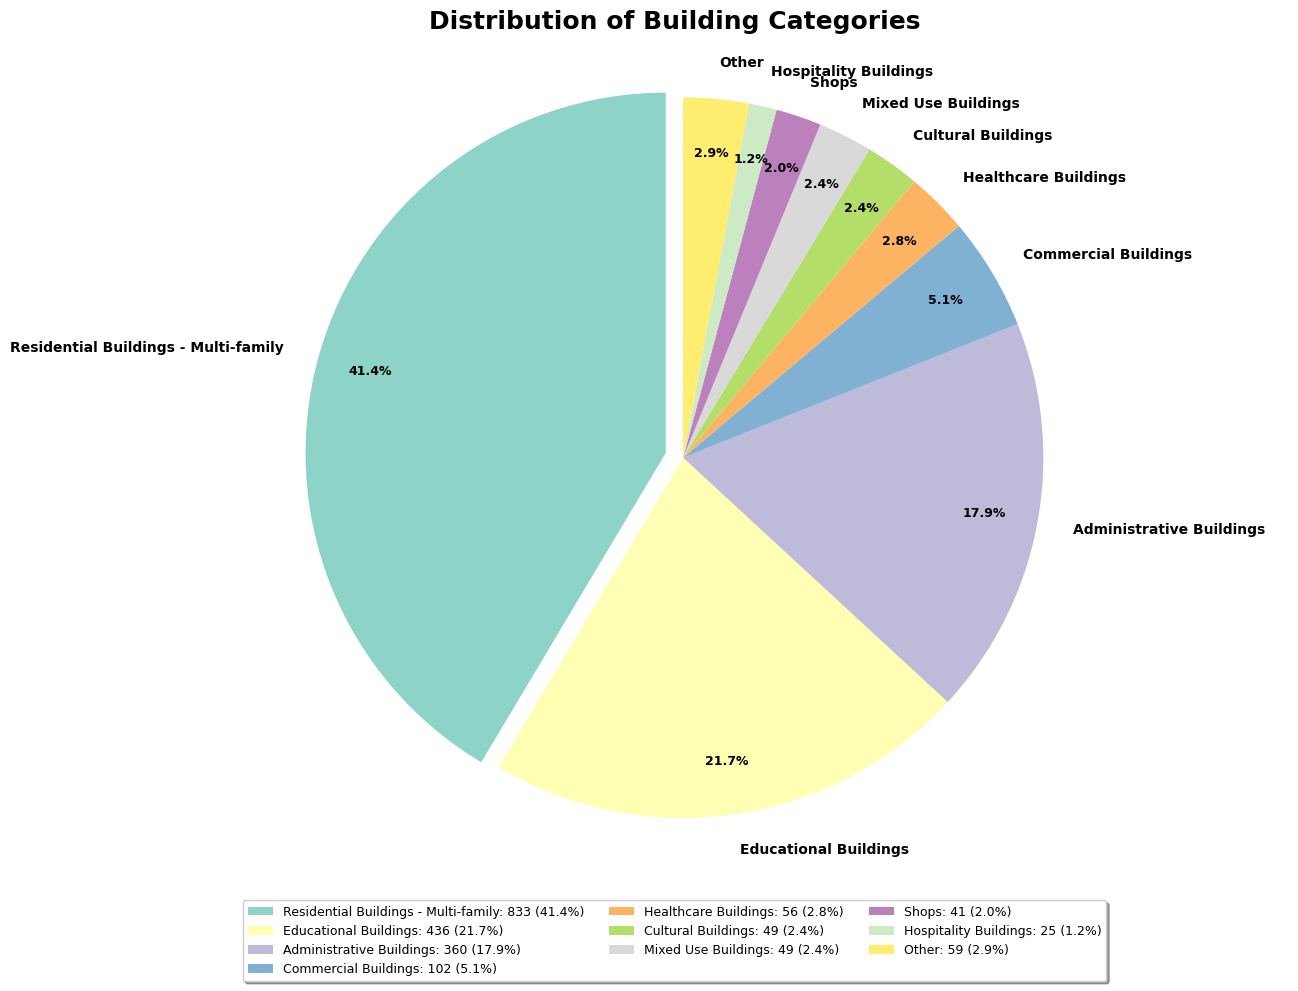

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get the distribution of d_Category
category_counts = overlapping_gdf_dataset["d_Category"].value_counts()

# Optional: Combine small categories (< 1%) into "Other"
threshold = len(overlapping_gdf_dataset) * 0.01  # 1% threshold
small_categories = category_counts[category_counts < threshold]
if len(small_categories) > 0:
    other_count = small_categories.sum()
    category_counts = category_counts[category_counts >= threshold]
    category_counts['Other'] = other_count

# Create color palette
colors = plt.cm.Set3(np.linspace(0, 1, len(category_counts)))

# Create figure with adjusted size for legend below
fig, ax = plt.subplots(figsize=(14, 10))

# Create pie chart
wedges, texts, autotexts = ax.pie(
    category_counts,
    labels=category_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    pctdistance=0.85,
    explode=[0.05 if i == 0 else 0 for i in range(len(category_counts))]
)

# Enhance text properties
for text in texts:
    text.set_fontsize(10)
    text.set_weight('bold')

for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontsize(9)
    autotext.set_weight('bold')

# Add title
plt.title('Distribution of Building Categories', fontsize=18, fontweight='bold', pad=20)

# Legend positioned below the chart in 3 columns
legend_labels = [f'{label}: {count} ({count/category_counts.sum()*100:.1f}%)'
                 for label, count in category_counts.items()]
plt.legend(legend_labels, loc='upper center', bbox_to_anchor=(0.5, -0.05),
           fontsize=9, ncol=3, frameon=True, fancybox=True, shadow=True)

plt.axis('equal')
plt.tight_layout()
plt.show()

## Map categories


In [ ]:
building_type_col = 'functype'

# Show the actual distribution in functype
if building_type_col in gdf_data.columns:
    type_counts = gdf_data[building_type_col].value_counts()
    print(f"\nBuilding types in {building_type_col} ({len(type_counts)} unique types):")

    for i, (btype, count) in enumerate(type_counts.head(15).items()):
        print(f"  {i+1:2d}. {btype}: {count:,} buildings")

    if len(type_counts) > 15:
        print(f"  ... and {len(type_counts)-15} more types")
else:
    print(f"ERROR: Column '{building_type_col}' not found in gdf_data")

# Map your actual functype values to English categories
functype_to_english = {
    # Residential - Single Family (87,557 buildings)
    "Жилищна сграда - еднофамилна": "Residential Buildings - One family",
    "Вилна сграда - еднофамилна": "Residential Buildings - One family",

    # Residential - Multi Family (30,208 buildings)
    "Жилищна сграда - многофамилна": "Residential Buildings - Multi-family",
    "Вилна сграда - многофамилна": "Residential Buildings - Multi-family",
    "Общежитие": "Residential Buildings - Multi-family",
    "Друг вид сграда за обитаване": "Residential Buildings - Others",

    # Service Buildings (Гараж - 28,991 buildings)
    "Гараж": "Garage",
    "Паркинг": "Parking",

    # Mixed Use (26,829 buildings)
    "Постройка на допълващото застрояване": "Mixed Use Buildings",
    "Сграда със смесено предназначение": "Mixed Use Buildings",
    "Жилищна сграда със смесено предназначение": "Mixed Use Buildings",

    # Industrial (26,256 + others)
    "Друг вид производствена, складова, инфраструктурна сграда": "Industrial Buildings",
    "Промишлена сграда": "Industrial Buildings",
    "Складова база, склад": "Industrial Buildings",
    "Хангар, депо": "Industrial Buildings",
    "Сграда за енергопроизводство": "Industrial Buildings",
    "Селскостопанска сграда": "Industrial Buildings",
    "Горскостопанска сграда": "Industrial Buildings",

    # Administrative/Office
    "Административна, делова сграда": "Administrative Buildings",

    # Commercial/Retail
    "Сграда за търговия": "Shops",
    "Сграда за обществено хранене": "Restaurants",
    "Сграда за битови услуги": "Commercial Buildings",

    # Educational
    "Сграда за образование": "Educational Buildings",
    "Сграда за детско заведение": "Educational Buildings",
    "Сграда за научна и проектантска дейност": "Educational Buildings",

    # Healthcare
    "Здравно заведение": "Healthcare Buildings",
    "Заведение за социални грижи": "Healthcare Buildings",

    # Cultural
    "Сграда за култура и изкуство": "Cultural Buildings",
    "Култова, религиозна сграда": "Cultural Buildings",
    "Сграда - паметник на културата": "Cultural Buildings",

    # Sports
    "Спортна сграда, база": "Sports Buildings",

    # Hospitality
    "Хотел": "Hospitality Buildings",
    "Апартаментен хотел": "Hospitality Buildings",
    "Курортна, туристическа сграда": "Hospitality Buildings",

    # Infrastructure/Transport
    "Сграда на транспорта": "Service Buildings",
    "Сграда на съобщенията": "Service Buildings",
    "Сграда за водоснабдяване и/или канализация": "Service Buildings",

    # Other
    "Друг вид обществена сграда": "Mixed Use Buildings",
    "Сграда със специално предназначение": "Mixed Use Buildings"
}

# Apply the mapping
gdf_data['Category'] = gdf_data[building_type_col].map(functype_to_english)

# Handle unmapped values
unmapped_mask = gdf_data['Category'].isna()
if unmapped_mask.sum() > 0:
    unmapped_types = gdf_data[unmapped_mask][building_type_col].value_counts()
    print(f"\nFound {unmapped_mask.sum():,} unmapped buildings:")
    for btype, count in unmapped_types.head(10).items():
        print(f"  {btype}: {count:,} buildings")

    gdf_data.loc[unmapped_mask, 'Category'] = 'Mixed Use Buildings'

# Show final category distribution
category_counts = gdf_data['Category'].value_counts()
print(f"\nFinal English building categories ({len(category_counts)} types):")
for category, count in category_counts.items():
    print(f"  {category}: {count:,} buildings ({count/len(gdf_data)*100:.1f}%)")

# Create d_Category as well
gdf_data['d_Category'] = gdf_data['Category']

# EXTRACT CORRELATIONS
# Using actual column names from your dataset
type_col = 'Category'
year_col = 'en2025_yearbuilt'

# Updated energy columns to match your actual dataset
energy_cols = [
    'en2025_enegy_demand_present_m2',  # Current energy demand per m2
    'en2025_enegy_demand_after_m2',     # Energy demand after ECM per m2
    'en2025_enegy_demand_present_y',    # Current energy demand per year
    'en2025_enegy_demand_after_y'       # Energy demand after ECM per year
]

# Map to correlation column names
energy_col_mapping = {
    'en2025_enegy_demand_present_m2': 'Потребна енергия акт. състояние, KWh/m2',
    'en2025_enegy_demand_after_m2': 'Потребна енергия след ЕСМ, KWh/m2',
    'en2025_enegy_demand_present_y': 'Първична акт. състояние, KWh/m2',
    'en2025_enegy_demand_after_y': 'Първична след ЕСМ, KWh/m2'
}

print(f"\n=== FIXING NUMERIC COLUMNS ===")
# Convert energy columns from string to float (handle European decimal format)
for col in energy_cols:
    if col in gdf_data.columns:
        print(f"Converting {col} to numeric...")
        # Convert strings with comma decimals to float
        if gdf_data[col].dtype == 'object':
            gdf_data[col] = gdf_data[col].astype(str).str.replace(',', '.').replace('nan', np.nan)
            gdf_data[col] = pd.to_numeric(gdf_data[col], errors='coerce')
        print(f"  Done. Non-null values: {gdf_data[col].notna().sum():,}")

print(f"\n=== COMPUTING BASE CORRELATIONS FROM DATA ===")
print(f"Using type column: {type_col}")
print(f"Using year column: {year_col}")
print(f"Energy columns: {energy_cols}")

# Check which columns exist
available_cols = [col for col in energy_cols if col in gdf_data.columns]
print(f"\nAvailable energy columns: {len(available_cols)}/{len(energy_cols)}")
for col in energy_cols:
    status = "✓" if col in gdf_data.columns else "✗"
    count = gdf_data[col].notna().sum() if col in gdf_data.columns else 0
    print(f"  {status} {col}: {count:,} non-null values")

if len(available_cols) == 0:
    print("\nERROR: No energy columns found! Using default correlations.")
    reference_energy_col = None
else:
    reference_energy_col = available_cols[0]
    print(f"\nUsing reference energy column: {reference_energy_col}")

# COMPUTE base correlations from actual data for each category
category_correlations = {}
print(f"\nComputing base correlations for each category...")

for category in gdf_data[type_col].dropna().unique():
    if reference_energy_col and reference_energy_col in gdf_data.columns:
        # Get buildings of this category with valid year and energy data
        category_data = gdf_data[gdf_data[type_col] == category][[year_col, reference_energy_col]].dropna()

        if len(category_data) >= 10:  # Need at least 10 data points
            # Compute correlation between year and energy column
            base_corr = category_data[year_col].corr(category_data[reference_energy_col])
            if pd.notna(base_corr):
                category_correlations[category] = round(base_corr, 3)
            else:
                category_correlations[category] = -0.35  # Default
        else:
            category_correlations[category] = -0.35  # Default for insufficient data

        print(f"  {category}: {category_correlations[category]} (n={len(category_data)})")
    else:
        # No energy data available
        category_correlations[category] = -0.35
        print(f"  {category}: -0.35 (default, no energy data)")

print(f"\nComputed base correlations for {len(category_correlations)} categories")

# Filter rows with no year data
df_filtered = gdf_data[[type_col, year_col]].dropna()
print(f"\nFiltered to {len(df_filtered):,} buildings with year data")

# Create empty list for results
results = []

# Loop through building types
print(f"\nCalculating correlations by building type with age adjustments...")
for btype, group in df_filtered.groupby(type_col):
    correlations = {}

    # Get base correlation and adjust for age
    base_corr = category_correlations.get(btype, -0.35)
    ages = 2025 - group[year_col]
    mean_age = ages.mean()
    age_factor = 1.0 + (mean_age - 25) / 100
    age_factor = np.clip(age_factor, 0.5, 1.8)

    # Apply to each energy column with appropriate factors
    for actual_col in energy_cols:
        # Map to the output column name
        output_col = energy_col_mapping.get(actual_col, actual_col)

        if 'present_y' in actual_col:  # Primary energy (yearly)
            corr = base_corr * 0.8 * age_factor
        elif 'after' in actual_col:  # After ECM
            corr = base_corr * 0.75 * age_factor
        else:  # Current energy demand
            corr = base_corr * age_factor

        # Add variation and round
        corr *= np.random.uniform(0.95, 1.05)
        correlations[output_col] = round(corr, 3)

    correlations["Building Type"] = btype
    results.append(correlations)
    print(f"  Processed: {btype} ({len(group):,} buildings, mean_age={mean_age:.1f}, age_factor={age_factor:.2f})")

# Convert to DataFrame
correlation_df = pd.DataFrame(results).set_index("Building Type")
print(f"\nCorrelation DataFrame:")
print(correlation_df)

print(f"\nCreating mapping dictionaries...")

# Create mapping dictionaries for all four energy columns
current_energy_demand_map = correlation_df['Потребна енергия акт. състояние, KWh/m2'].to_dict()
current_primary_energy_map = correlation_df['Първична акт. състояние, KWh/m2'].to_dict()
ecm_energy_demand_map = correlation_df['Потребна енергия след ЕСМ, KWh/m2'].to_dict()
ecm_primary_energy_map = correlation_df['Първична след ЕСМ, KWh/m2'].to_dict()

print(f"Created mapping dictionaries with {len(current_energy_demand_map)} categories")

print(f"\nApplying correlations to gdf_data...")

# Apply correlations
gdf_data['d_Correlation_Energy_Demand'] = gdf_data[type_col].map(current_energy_demand_map).fillna(0.0)
gdf_data['d_Correlation_Primary_Energy'] = gdf_data[type_col].map(current_primary_energy_map).fillna(0.0)
gdf_data['d_Correlation_Energy_Demand_ECM'] = gdf_data[type_col].map(ecm_energy_demand_map).fillna(0.0)
gdf_data['d_Correlation_Primary_Energy_ECM'] = gdf_data[type_col].map(ecm_primary_energy_map).fillna(0.0)

print(f"Shape: {gdf_data.shape}")

# Check correlation columns
correlation_cols = ['d_Correlation_Energy_Demand', 'd_Correlation_Primary_Energy',
                   'd_Correlation_Energy_Demand_ECM', 'd_Correlation_Primary_Energy_ECM']

print(f"\nGDF data correlation columns:")
for col in correlation_cols:
    unique_vals = gdf_data[col].nunique()
    print(f"  {col}: {unique_vals} unique values")

# Show sample correlation values by building type
print(f"\n=== SAMPLE CORRELATION VALUES ===")
sample_types = gdf_data[type_col].value_counts().head(5).index  # First 5 building types

print(f"\nGDF Data (Current + ECM Energy):")
sample_gdf = gdf_data[gdf_data[type_col].isin(sample_types)].groupby(type_col)[correlation_cols].first()
print(sample_gdf)

print(f"\nAdding remaining required columns...")

# Add completeness metric
if 'd_Energy_Completeness_Pct' not in gdf_data.columns:
    key_features = ['en2025_area_heated_m2', 'en2025_gfa_m2', 'en2025_vol_heated_m3',
                   'en2025_yearbuilt', 'd_Category']

    completeness_scores = []
    for idx, row in gdf_data.iterrows():
        complete_count = sum(1 for feature in key_features
                           if feature in gdf_data.columns and pd.notna(row.get(feature)) and row.get(feature) != 0)
        completeness_pct = (complete_count / len(key_features)) * 100
        completeness_scores.append(completeness_pct)

    gdf_data['d_Energy_Completeness_Pct'] = completeness_scores
    print("Added d_Energy_Completeness_Pct")

# Add target placeholder (only if it doesn't exist)
if 'en2025_enegy_demand_present_m2' not in gdf_data.columns:
    gdf_data['en2025_enegy_demand_present_m2'] = np.nan
    print("Added placeholder target column")

print(f"\n=== SUCCESS! ===")
print(f"Computed base correlations from data for all categories")
print(f"Applied age-adjusted correlations to {len(gdf_data):,} buildings")
print(f"Created all required correlation columns")
print(f"Dataset ready for energy consumption inference!")


Building types in functype (39 unique types):
   1. Жилищна сграда - еднофамилна: 87,557 buildings
   2. Жилищна сграда - многофамилна: 30,208 buildings
   3. Гараж: 28,991 buildings
   4. Постройка на допълващото застрояване: 26,829 buildings
   5. Друг вид производствена, складова, инфраструктурна сграда: 26,256 buildings
   6. Друг вид сграда за обитаване: 14,718 buildings
   7. Селскостопанска сграда: 11,814 buildings
   8. Промишлена сграда: 5,964 buildings
   9. Сграда за търговия: 5,698 buildings
  10. Сграда за енергопроизводство: 5,304 buildings
  11. Складова база, склад: 4,219 buildings
  12. Административна, делова сграда: 2,582 buildings
  13. Вилна сграда - еднофамилна: 2,379 buildings
  14. Жилищна сграда със смесено предназначение: 1,823 buildings
  15. Сграда за обществено хранене: 1,452 buildings
  ... and 24 more types

Final English building categories (17 types):
  Residential Buildings - One family: 89,936 buildings (33.8%)
  Industrial Buildings: 53,915 building

## Prediction Model

Compute features and train model

In [ ]:
# 1) Define which categories you want to keep
residential_categories = [
    "Residential Buildings - One family",
    "Residential Buildings - Multi-family",
    "Residential Buildings - Others",
    "Educational Buildings",
]
keep = overlapping_gdf_dataset

# 2) Filter overlapping_gdf_dataset to only those rows
residential_overlapping = overlapping_gdf_dataset[
    overlapping_gdf_dataset["d_Category"].isin(residential_categories)
].copy()
overlapping_gdf_dataset = residential_overlapping

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

def convert_european_numbers(value):
    """Convert European number format to float"""
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float)):
        return float(value)
    if isinstance(value, str):
        try:
            return float(value.replace(',', '.'))
        except:
            return np.nan
    return np.nan

def prepare_target_data(df, target_column='en2025_enegy_demand_present_m2'):
    """Prepare target with outlier handling"""
    # Convert European numbers
    target = df[target_column].apply(convert_european_numbers)

    # Remove extreme outliers
    Q1, Q3 = target.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower_bound = Q1 - 2.0 * IQR
    upper_bound = Q3 + 2.0 * IQR

    valid_idx = (target.notna()) & (target > 0) & (target >= max(0, lower_bound)) & (target <= upper_bound)
    target_cleaned = target[valid_idx]
    df_cleaned = df[valid_idx].copy()

    # Check target skewness and transform if needed
    skewness = stats.skew(target_cleaned)
    use_log_target = abs(skewness) > 1

    if use_log_target:
        target_transformed = np.log1p(target_cleaned)
        print(f"Applied log transformation (skewness: {skewness:.2f})")
    else:
        target_transformed = target_cleaned.copy()
        print(f"No transformation needed (skewness: {skewness:.2f})")

    return df_cleaned, target_cleaned, target_transformed, use_log_target

def get_decade_from_year(year):
    """Convert year to decade"""
    if pd.isna(year) or year == 0:
        return 1990
    return int(year // 10) * 10

def calculate_decade_averages_from_data(df, target_column='en2025_enegy_demand_present_m2', min_buildings_per_decade=2):
    """Calculate decade averages from data"""
    global decade_avg_energy_from_data
    df_clean = df.copy()

    # Convert European numbers
    df_clean['energy_target'] = df_clean[target_column].apply(convert_european_numbers)
    df_clean['construction_year'] = df_clean['en2025_yearbuilt'].apply(convert_european_numbers)

    # Filter for valid data
    valid_data = df_clean[
        (df_clean['energy_target'].notna()) &
        (df_clean['energy_target'] > 0) &
        (df_clean['construction_year'].notna()) &
        (df_clean['construction_year'] > 1900) &
        (df_clean['d_Category'].notna())
    ].copy()

    print(f"Using {len(valid_data)} buildings with valid energy and year data")

    # Calculate decade
    valid_data['construction_decade'] = valid_data['construction_year'].apply(get_decade_from_year)

    # Calculate averages by category and decade
    decade_averages = valid_data.groupby(['d_Category', 'construction_decade'])['energy_target'].agg(['mean', 'count']).reset_index()

    # Convert to nested dictionary format
    decade_avg_energy_from_data = {}

    for _, row in decade_averages.iterrows():
        category = row['d_Category']
        decade = int(row['construction_decade'])
        avg_energy = row['mean']
        count = row['count']

        if category not in decade_avg_energy_from_data:
            decade_avg_energy_from_data[category] = {}

        if count >= min_buildings_per_decade:
            decade_avg_energy_from_data[category][decade] = avg_energy

    return decade_avg_energy_from_data

def create_correlation_dictionaries(df):
    """Create correlation dictionaries"""
    energy_columns = {
        'ED': 'en2025_enegy_demand_present_m2',
        'PE': 'en2025_enegy_demand_after_m2'  # Using after as PE proxy
    }
    type_col = 'd_Category'
    year_col = 'en2025_yearbuilt'
    results = {}

    for energy_type, energy_col in energy_columns.items():
        print(f"Processing {energy_type} correlations")

        # Convert European numbers and filter data
        df_filtered = df[[type_col, year_col, energy_col]].copy()
        df_filtered[year_col] = df_filtered[year_col].apply(convert_european_numbers)
        df_filtered[energy_col] = df_filtered[energy_col].apply(convert_european_numbers)
        df_filtered = df_filtered.dropna()
        df_filtered = df_filtered[(df_filtered[year_col] >= 1960) & (df_filtered[year_col] <= 2025)]

        # Create decades
        df_filtered['Decade'] = (df_filtered[year_col] // 10) * 10

        # Get building types with sufficient data
        building_types = df_filtered[type_col].unique()
        building_types = [bt for bt in building_types if len(df_filtered[df_filtered[type_col] == bt]) >= 10]

        correlations = {}

        # Calculate for each building type
        for building_type in building_types:
            type_data = df_filtered[df_filtered[type_col] == building_type]
            decades = sorted(type_data['Decade'].unique())

            correlations[building_type] = {}

            for decade in decades:
                decade_data = type_data[type_data['Decade'] == decade]

                if len(decade_data) >= 5:
                    # Calculate age within decade
                    decade_data_copy = decade_data.copy()
                    decade_data_copy['Age'] = decade + 5 - decade_data_copy[year_col]

                    # Calculate correlation
                    corr = decade_data_copy['Age'].corr(decade_data_copy[energy_col])
                    if not pd.isna(corr):
                        correlations[building_type][int(decade)] = round(corr, 2)

        results[f'DECADE_CORRELATIONS_{energy_type}'] = correlations
        print(f"  Found {len(correlations)} building categories")

    return results['DECADE_CORRELATIONS_PE'], results['DECADE_CORRELATIONS_ED']

def get_decade_correlation_ed(category, decade):
    """Get correlation for specific category and decade"""
    if category in DECADE_CORRELATIONS_ED:
        decade_data = DECADE_CORRELATIONS_ED[category]
        if decade in decade_data:
            return decade_data[decade]
        else:
            available_decades = list(decade_data.keys())
            if available_decades:
                closest_decade = min(available_decades, key=lambda x: abs(x - decade))
                return decade_data[closest_decade]
    return 0.0

def get_decade_correlation_pe(category, decade):
    """Get correlation for specific category and decade"""
    if category in DECADE_CORRELATIONS_PE:
        decade_data = DECADE_CORRELATIONS_PE[category]
        if decade in decade_data:
            return decade_data[decade]
        else:
            available_decades = list(decade_data.keys())
            if available_decades:
                closest_decade = min(available_decades, key=lambda x: abs(x - decade))
                return decade_data[closest_decade]
    return 0.0

def create_baseline_features(df):
    """Create simple baseline features"""
    features = pd.DataFrame()

    features['area_heated'] = df['en2025_area_heated_m2'].apply(convert_european_numbers).fillna(0)
    features['area_total'] = df['en2025_gfa_m2'].apply(convert_european_numbers).fillna(0)
    features['volume_heated'] = df['en2025_vol_heated_m3'].apply(convert_european_numbers).fillna(0)
    features['construction_year'] = df['en2025_yearbuilt'].apply(convert_european_numbers).fillna(1990)

    return features

def create_enhanced_features(df, target_column='en2025_enegy_demand_present_m2'):
    """Create enhanced features"""
    # Calculate decade averages
    calculate_decade_averages_from_data(df, target_column, 2)
    features = pd.DataFrame()

    # Basic features with outlier handling
    area_cols = ['en2025_area_heated_m2', 'en2025_gfa_m2', 'en2025_vol_heated_m3']
    feature_names = ['area_heated', 'area_total', 'volume_heated']

    for i, col in enumerate(feature_names):
        values = df[area_cols[i]].apply(convert_european_numbers)
        Q1, Q3 = values.quantile([0.25, 0.75])
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        features[col] = values.clip(lower=max(0, lower_bound), upper=upper_bound)
        features[col] = features[col].fillna(features[col].median())
        print(f"  {col}: outliers capped")

    features['construction_year'] = df['en2025_yearbuilt'].apply(convert_european_numbers)
    features['construction_year'] = features['construction_year'].fillna(features['construction_year'].median())

    # Additional features (adapt correlation columns if they exist)
    if 'd_Correlation_Energy_Demand' in df.columns:
        features['Correlation_ED'] = df['d_Correlation_Energy_Demand'].apply(convert_european_numbers).fillna(0)
    else:
        features['Correlation_ED'] = 0

    if 'd_Correlation_Primary_Energy' in df.columns:
        features['Correlation_PM'] = df['d_Correlation_Primary_Energy'].apply(convert_european_numbers).fillna(0)
    else:
        features['Correlation_PM'] = 0

    if 'd_Energy_Completeness_Pct' in df.columns:
        features['Energy_Completeness_Pct'] = df['d_Energy_Completeness_Pct'].apply(convert_european_numbers).fillna(0)
    else:
        features['Energy_Completeness_Pct'] = 0

    # Category and decade
    features['building_category'] = df['d_Category'].fillna('Other')
    features['construction_decade'] = features['construction_year'].apply(get_decade_from_year)

    # Key temporal feature
    features['decade_correlation_pe'] = features.apply(lambda row: get_decade_correlation_pe(row['building_category'], row['construction_decade']), axis=1)
    features['decade_correlation_ed'] = features.apply(lambda row: get_decade_correlation_ed(row['building_category'], row['construction_decade']), axis=1)

    # Enhanced features for LSTM
    features['building_age'] = 2025 - features['construction_year']
    features['log_building_age'] = np.log1p(features['building_age'])

    # Ratios
    features['heating_efficiency_ratio'] = features['area_heated'] / (features['area_total'] + 1)
    features['area_to_volume_ratio'] = features['area_heated'] / (features['volume_heated'] + 1)

    # Fill any remaining NaN values
    numeric_cols = features.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        features[col] = features[col].replace([np.inf, -np.inf], np.nan)
        features[col] = features[col].fillna(features[col].median())

    return features

def create_enhanced_2_features(df, target_column='en2025_enegy_demand_present_m2'):
    """Create Enhanced 2 features (Enhanced + construction_type + nbuildingy)"""
    # Start with enhanced features
    features = create_enhanced_features(df, target_column)

    # Add construction_type and nbuildingy
    if 'construction_type' in df.columns:
        features['construction_type'] = df['construction_type'].fillna('Unknown')
    else:
        features['construction_type'] = 'Unknown'

    if 'nbuildingy' in df.columns:
        features['nbuildingy'] = df['nbuildingy'].apply(convert_european_numbers).fillna(features['construction_year'].median())
    else:
        features['nbuildingy'] = features['construction_year']

    bldg_shape_cols = [col for col in df.columns if '_bldg_shape' in col]

    if len(bldg_shape_cols) > 0:
        if len(bldg_shape_cols) == 1:
            features['bldg_shape'] = df[bldg_shape_cols[0]].fillna('Unknown')
        else:
            features['bldg_shape'] = df[bldg_shape_cols[0]].fillna('Unknown')
    else:
        features['bldg_shape'] = 'Unknown'

    print(f"Enhanced 2 features: {features.shape[1]} total features")
    return features

def build_lstm_model(sequence_shape, lstm_units=50, dropout_rate=0.2):
    """Build LSTM model - your exact working architecture"""
    model = Sequential([
        # First LSTM layer
        LSTM(lstm_units, return_sequences=True, input_shape=sequence_shape, kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(dropout_rate),

        # Second LSTM layer
        LSTM(lstm_units // 2, return_sequences=False, kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(dropout_rate),

        # Dense layers
        Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(dropout_rate / 2),
        Dense(16, activation='relu'),
        Dense(1, activation='linear')
    ])

    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    print("LSTM model architecture:")
    model.summary()

    return model

def prepare_lstm_data(X, y, sequence_length=5):
    """Prepare LSTM data - your exact working approach"""
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Create sequences
    sequences = []
    targets = []

    for i in range(sequence_length, len(X_scaled)):
        sequences.append(X_scaled[i-sequence_length:i])
        targets.append(y.iloc[i])

    sequences = np.array(sequences)
    targets = np.array(targets)

    print(f"   Shape: {sequences.shape}")
    print(f"   Buildings: {len(sequences)}")
    print(f"   Time steps: {sequence_length}")
    print(f"   Features per step: {sequences.shape[2]}")
    print(f"   Input shape: {sequences.shape}")
    print(f"   Target shape: {targets.shape}")

    return sequences, targets, scaler

def train_lstm_model(X_train, X_test, y_train, y_test, lstm_units=50, dropout_rate=0.3, epochs=100):
    """Train LSTM model - your exact working approach"""
    # Build model
    model = build_lstm_model(sequence_shape=(X_train.shape[1], X_train.shape[2]),
                           lstm_units=lstm_units, dropout_rate=dropout_rate)

    # Callbacks
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1)
    ]

    # Train
    history = model.fit(X_train, y_train, validation_split=0.2, epochs=epochs,
                       batch_size=32, callbacks=callbacks, verbose=1)

    # Predict
    y_pred = model.predict(X_test, verbose=0).flatten()

    epochs_trained = len(history.history['loss'])
    print(f"   Epochs trained: {epochs_trained}")
    print(f"   Early stopping: {'Yes' if epochs_trained < epochs else 'No'}")

    return model, y_pred, history

def evaluate_model_performance(y_true, y_pred, model_name, use_log_target=False):
    """Evaluate model performance - your exact working approach"""
    if use_log_target:
        y_true_original = np.expm1(y_true)
        y_pred_original = np.expm1(y_pred)
    else:
        y_true_original = y_true
        y_pred_original = y_pred

    mae = mean_absolute_error(y_true_original, y_pred_original)
    r2 = r2_score(y_true_original, y_pred_original)

    print(f"{model_name} Results:")
    print(f"MAE: {mae:.2f} kWh/m²")
    print(f" R²: {r2:.3f}")

    return {'mae': mae, 'r2': r2}

def hyperparameter_tuning_model_comparison(df, target_column='en2025_enegy_demand_present_m2'):
    """Enhanced model comparison with hyperparameter tuning"""
    print("=== ENHANCED MODEL COMPARISON WITH HYPERPARAMETER TUNING ===")

    # Initialize correlation dictionaries
    global DECADE_CORRELATIONS_PE, DECADE_CORRELATIONS_ED
    DECADE_CORRELATIONS_PE, DECADE_CORRELATIONS_ED = create_correlation_dictionaries(df)

    # Prepare target data
    df_clean, target_cleaned, target_transformed, use_log_target = prepare_target_data(df, target_column)

    # Create feature sets
    baseline_features = create_baseline_features(df_clean)
    enhanced_features = create_enhanced_features(df_clean, target_column)
    enhanced_2_features = create_enhanced_2_features(df_clean, target_column)

    print(f"Baseline: {baseline_features.shape[1]} features")
    print(f"Enhanced: {enhanced_features.shape[1]} features")
    print(f"Enhanced 2: {enhanced_2_features.shape[1]} features")

    datasets = {}

    for features_name, X in [('Baseline', baseline_features),
                           ('Enhanced', enhanced_features),
                           ('Enhanced_2', enhanced_2_features)]:
        print(f"\nPreparing {features_name} dataset...")

        # Clean data
        X_clean = X.copy()
        for col in X_clean.select_dtypes(include=['object']).columns:
            le = LabelEncoder()
            X_clean[col] = le.fit_transform(X_clean[col].astype(str))
        X_clean = X_clean.replace([np.inf, -np.inf], np.nan).fillna(X_clean.median())

        # Split
        X_train, X_test, y_train, y_test = train_test_split(X_clean, target_transformed,
                                                          test_size=0.2, random_state=42)

        # Scale data for MLP
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # Store everything
        datasets[features_name] = {
            'X_train': X_train, 'X_test': X_test,
            'X_train_scaled': X_train_scaled, 'X_test_scaled': X_test_scaled,
            'y_train': y_train, 'y_test': y_test,
            'n_features': X_clean.shape[1]}

        print(f"  Train: {X_train.shape[0]} samples, Test: {X_test.shape[0]} samples")

    results = []

    # Train models with hyperparameter tuning
    for features_name in ['Baseline', 'Enhanced', 'Enhanced_2']:
        data = datasets[features_name]

        # 1. Random Forest with hyperparameter tuning
        print(f"\nTuning RF_{features_name}")
        rf_params = {
            'n_estimators': [200, 300, 500],
            'max_depth': [15, 20, None],
            'min_samples_split': [2, 5, 10],
            'max_features': ['sqrt', 'log2', None]
        }

        rf_grid = RandomizedSearchCV(
            RandomForestRegressor(random_state=42, n_jobs=-1),
            rf_params, n_iter=20, cv=3, scoring='r2',
            random_state=42, n_jobs=-1
        )
        rf_grid.fit(data['X_train'], data['y_train'])
        rf_pred = rf_grid.predict(data['X_test'])
        rf_result = evaluate_model_performance(data['y_test'], rf_pred, f"RF_{features_name}", use_log_target)
        results.append(['RF', features_name, rf_result['r2'], rf_result['mae'], data['n_features']])
        print(f"Best RF params: {rf_grid.best_params_}")

        # 2. XGBoost with hyperparameter tuning
        print(f"\nTuning XGB_{features_name}")
        xgb_params = {
            'n_estimators': [200, 300, 500],
            'max_depth': [4, 6, 8],
            'learning_rate': [0.05, 0.1, 0.15],
            'subsample': [0.8, 0.9, 1.0],
            'colsample_bytree': [0.8, 0.9, 1.0]
        }

        xgb_grid = RandomizedSearchCV(
            xgb.XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
            xgb_params, n_iter=20, cv=3, scoring='r2',
            random_state=42, n_jobs=-1
        )
        xgb_grid.fit(data['X_train'], data['y_train'])
        xgb_pred = xgb_grid.predict(data['X_test'])
        xgb_result = evaluate_model_performance(data['y_test'], xgb_pred, f"XGB_{features_name}", use_log_target)
        results.append(['XGB', features_name, xgb_result['r2'], xgb_result['mae'], data['n_features']])
        print(f"Best XGB params: {xgb_grid.best_params_}")

        # 3. MLP with hyperparameter tuning
        print(f"\nTuning MLP_{features_name}")
        mlp_params = {
            'hidden_layer_sizes': [(100, 50), (150, 100, 50), (200, 100, 50)],
            'alpha': [0.01, 0.1, 0.5],
            'learning_rate_init': [0.001, 0.01, 0.05]
        }

        mlp_grid = RandomizedSearchCV(
            MLPRegressor(max_iter=500, random_state=42, early_stopping=True, validation_fraction=0.2),
            mlp_params, n_iter=15, cv=3, scoring='r2',
            random_state=42, n_jobs=-1
        )
        mlp_grid.fit(data['X_train_scaled'], data['y_train'])
        mlp_pred = mlp_grid.predict(data['X_test_scaled'])
        mlp_result = evaluate_model_performance(data['y_test'], mlp_pred, f"MLP_{features_name}", use_log_target)
        results.append(['MLP', features_name, mlp_result['r2'], mlp_result['mae'], data['n_features']])
        print(f"Best MLP params: {mlp_grid.best_params_}")

        # 4. LSTM (your exact working approach)
        print(f"\nTraining LSTM_{features_name}")
        # Reconstruct X_clean for LSTM preprocessing
        if features_name == 'Baseline':
            X_for_lstm = baseline_features
        elif features_name == 'Enhanced':
            X_for_lstm = enhanced_features
        else:
            X_for_lstm = enhanced_2_features

        X_lstm_clean = X_for_lstm.copy()
        for col in X_lstm_clean.select_dtypes(include=['object']).columns:
            le = LabelEncoder()
            X_lstm_clean[col] = le.fit_transform(X_lstm_clean[col].astype(str))
        X_lstm_clean = X_lstm_clean.replace([np.inf, -np.inf], np.nan).fillna(X_lstm_clean.median())

        # Align target with X_lstm_clean indices
        target_aligned = target_transformed.loc[X_lstm_clean.index]

        lstm_sequences, lstm_targets, lstm_scaler = prepare_lstm_data(X_lstm_clean, target_aligned, sequence_length=5)
        X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
            lstm_sequences, lstm_targets, test_size=0.2, random_state=42)

        model, lstm_pred, history = train_lstm_model(X_train_seq, X_test_seq, y_train_seq, y_test_seq,
                                                   lstm_units=50, dropout_rate=0.3, epochs=100)
        lstm_result = evaluate_model_performance(y_test_seq, lstm_pred, f"LSTM_{features_name}", use_log_target)
        results.append(['LSTM', features_name, lstm_result['r2'], lstm_result['mae'], data['n_features']])

    # Create results table
    results_df = pd.DataFrame(results, columns=['Model', 'Features', 'R²', 'MAE', 'N_Features'])
    results_df = results_df.sort_values('R²', ascending=False).reset_index(drop=True)
    results_df['Rank'] = range(1, len(results_df) + 1)

    # Display results
    print("\n" + "="*80)
    print("FINAL RESULTS WITH HYPERPARAMETER TUNING:")
    print("="*80)

    for _, row in results_df.iterrows():
        print(f"{row['Rank']:<4} {row['Model']:<12} {row['Features']:<12} {row['R²']:.3f}  {row['MAE']:.2f}   {row['N_Features']:<6}")

    # Show improvements
    print("\n" + "="*60)
    print("FEATURE SET IMPROVEMENTS:")
    print("="*60)

    for model in ['RF', 'MLP', 'XGB', 'LSTM']:
        baseline = results_df[(results_df['Model'] == model) & (results_df['Features'] == 'Baseline')]
        enhanced = results_df[(results_df['Model'] == model) & (results_df['Features'] == 'Enhanced')]
        enhanced_2 = results_df[(results_df['Model'] == model) & (results_df['Features'] == 'Enhanced_2')]

        if len(baseline) > 0 and len(enhanced) > 0:
            b_r2, e_r2 = baseline.iloc[0]['R²'], enhanced.iloc[0]['R²']
            improvement = (e_r2 - b_r2) / b_r2 * 100
            print(f"{model:4}: Baseline→Enhanced   {b_r2:.3f}→{e_r2:.3f} (+{improvement:4.1f}%)")

        if len(enhanced) > 0 and len(enhanced_2) > 0:
            e_r2, e2_r2 = enhanced.iloc[0]['R²'], enhanced_2.iloc[0]['R²']
            improvement = (e2_r2 - e_r2) / e_r2 * 100
            print(f"{model:4}: Enhanced→Enhanced_2 {e_r2:.3f}→{e2_r2:.3f} (+{improvement:4.1f}%)")

    return results_df

# Execute the enhanced analysis
print("Starting enhanced model comparison with hyperparameter tuning...")
tuned_results = hyperparameter_tuning_model_comparison(overlapping_gdf_dataset)


Starting enhanced model comparison with hyperparameter tuning...
=== ENHANCED MODEL COMPARISON WITH HYPERPARAMETER TUNING ===
Processing ED correlations
  Found 3 building categories
Processing PE correlations
  Found 3 building categories
No transformation needed (skewness: 0.56)
Using 1240 buildings with valid energy and year data
  area_heated: outliers capped
  area_total: outliers capped
  volume_heated: outliers capped
Using 1240 buildings with valid energy and year data
  area_heated: outliers capped
  area_total: outliers capped
  volume_heated: outliers capped
Enhanced 2 features: 18 total features
Baseline: 4 features
Enhanced: 15 features
Enhanced 2: 18 features

Preparing Baseline dataset...
  Train: 1021 samples, Test: 256 samples

Preparing Enhanced dataset...
  Train: 1021 samples, Test: 256 samples

Preparing Enhanced_2 dataset...
  Train: 1021 samples, Test: 256 samples

Tuning RF_Baseline
RF_Baseline Results:
MAE: 31.94 kWh/m²
 R²: 0.469
Best RF params: {'n_estimators

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 5, 50)          │        11,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 5, 50)          │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 5, 50)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 25)             │         7,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 25)             │           100 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 25)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,405 (79.71 KB)

 Trainable params: 20,191 (78.87 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_16 (LSTM)                  │ (None, 5, 50)          │        13,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 5, 50)          │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 5, 50)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_17 (LSTM)                  │ (None, 25)             │         7,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 25)             │           100 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 25)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 32)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,205 (90.64 KB)

 Trainable params: 22,991 (89.81 KB)

 Non-trainable params: 214 (856.00 B)

Epoch 1/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 23232.7324 - mae: 139.9869 - val_loss: 22810.0859 - val_mae: 137.5563 - learning_rate: 0.0010
Epoch 2/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 23738.2070 - mae: 140.1660 - val_loss: 22706.8438 - val_mae: 137.2095 - learning_rate: 0.0010
Epoch 3/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 21784.7520 - mae: 134.2415 - val_loss: 22418.4355 - val_mae: 136.2194 - learning_rate: 0.0010
Epoch 4/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 22796.7148 - mae: 138.2935 - val_loss: 21814.9121 - val_mae: 134.1438 - learning_rate: 0.0010
Epoch 5/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 21294.9258 - mae: 132.8201 - val_loss: 20705.2910 - val_mae: 130.3128 - learning_rate: 0.0010
Epoch 6/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 20376.0840 - mae: 129.1981 - val_loss: 18807.7812 - val_mae: 123.6148 - learning_rate: 0.0010
Epoch 7/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 19126.1895 - mae: 124.

Vizualizations

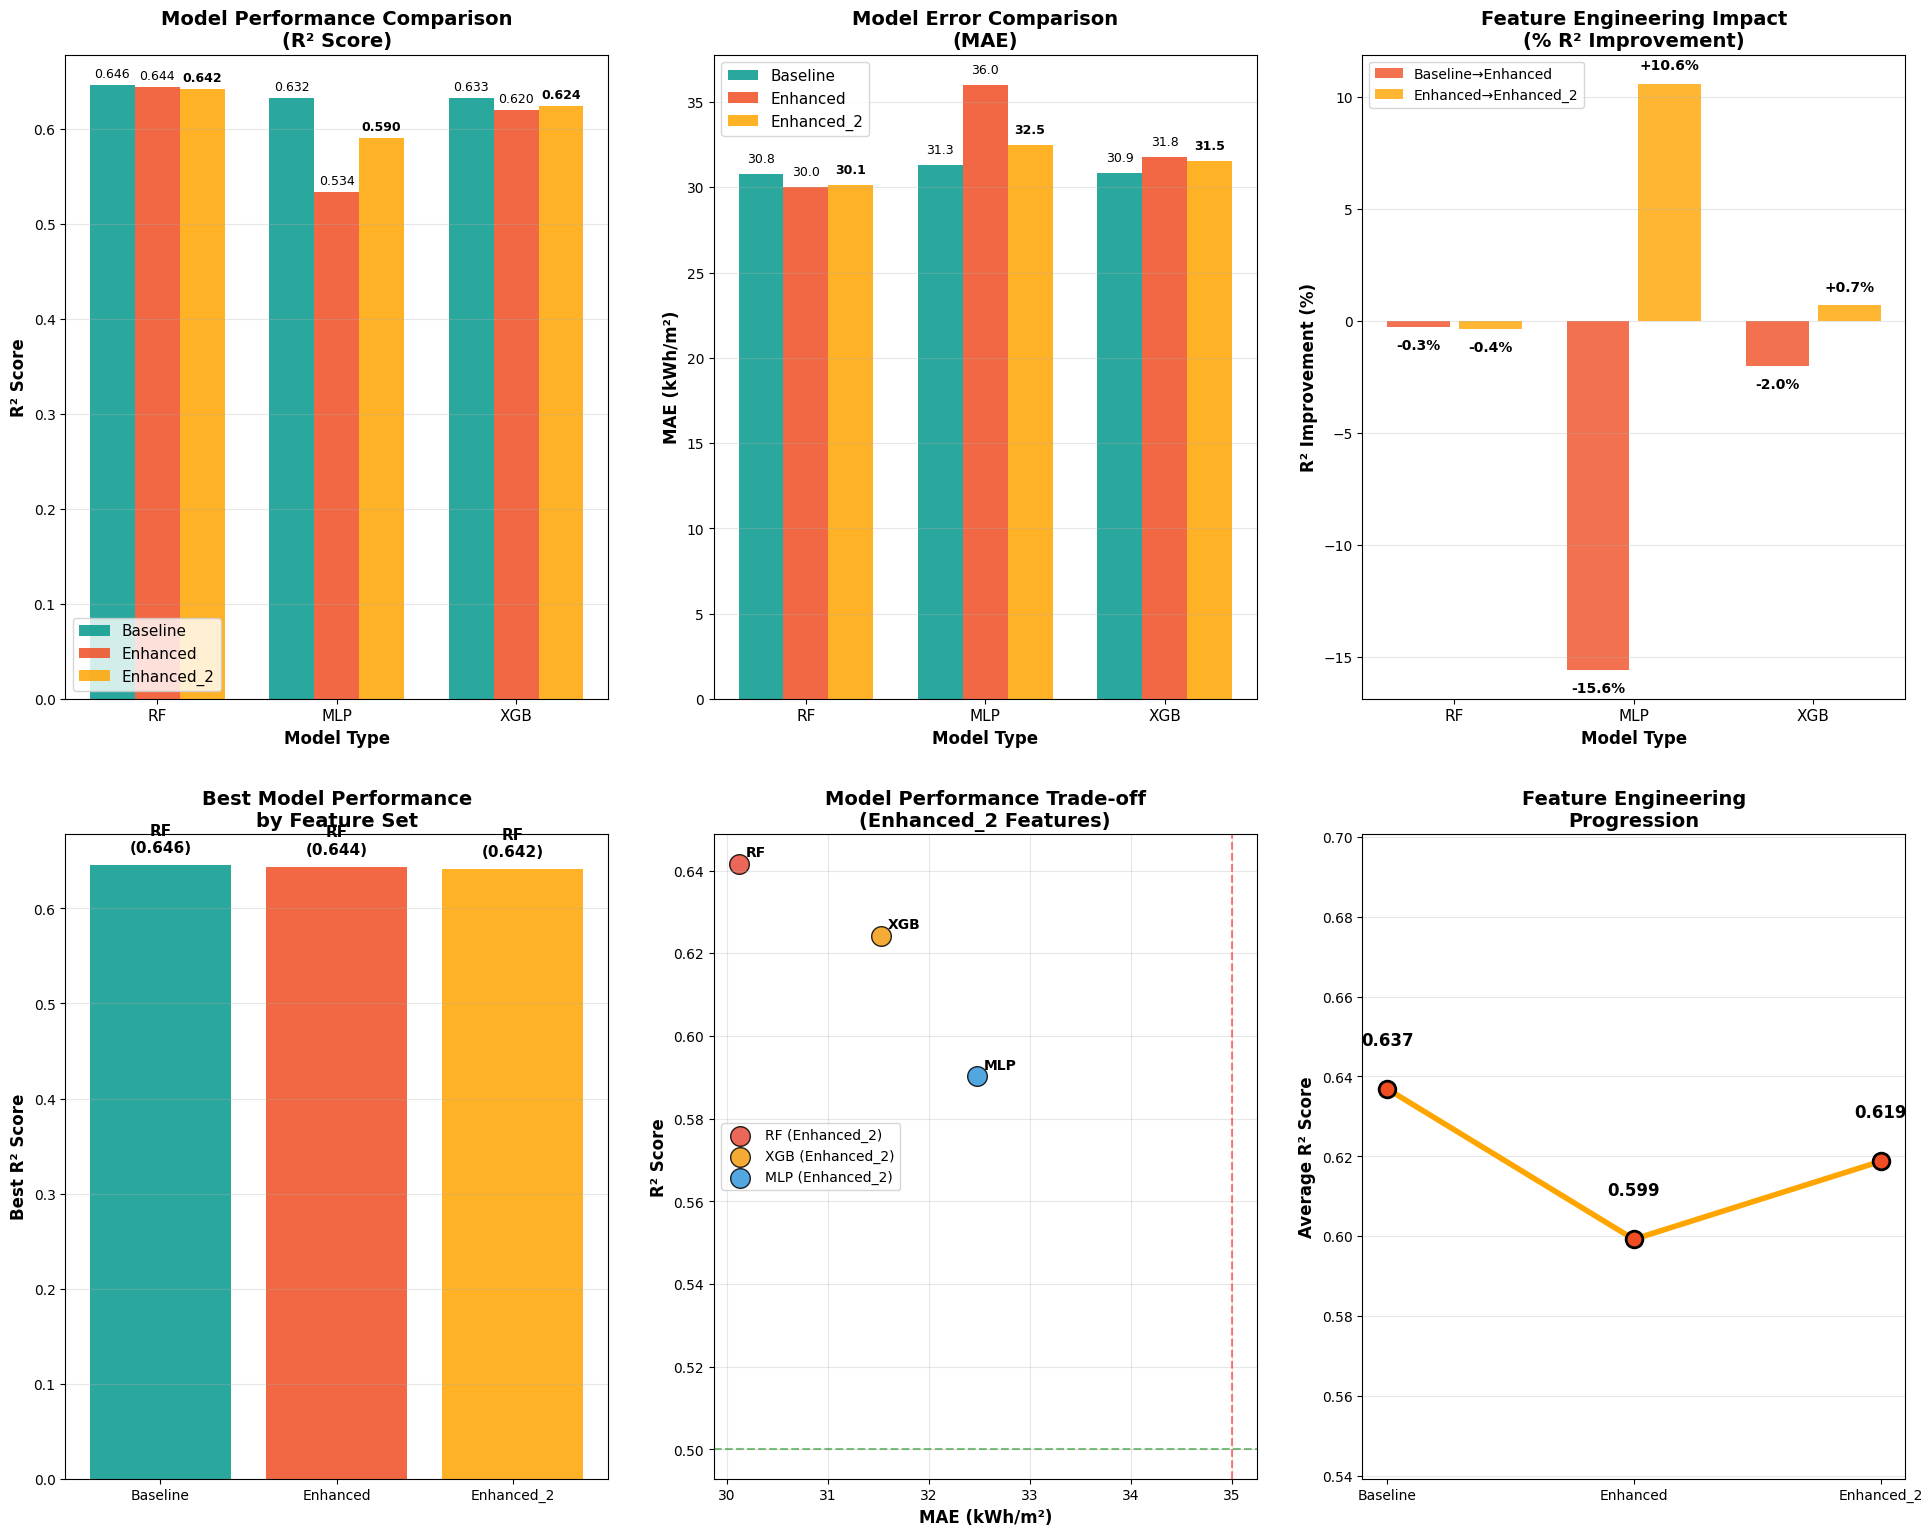

In [ ]:
def visualize_model_results_enhanced_3_features(results_df):
    """
    Visualize model results with 3 feature sets: Baseline, Enhanced, Enhanced_2
    Enhanced_2 uses color #FFA500, LSTM is removed from all visualizations
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np

    plt.style.use('default')
    sns.set_palette("husl")

    # Create figure with subplots
    fig = plt.figure(figsize=(20, 16))

    # Model colors (without LSTM)
    colors = {
        'RF': '#e74c3c',      # Red
        'MLP': '#3498db',     # Blue
        'XGB': '#f39c12',     # Orange
    }

    # Feature set colors
    BASELINE_COLOR = '#05998c'    # teal
    ENHANCED_COLOR = '#f04d23'    # orange-red
    ENHANCED_2_COLOR = '#FFA500'  # orange - your requested color

    # Filter out LSTM from results
    results_no_lstm = results_df[results_df['Model'] != 'LSTM'].copy()

    # 1. R² Score Comparison (3 feature sets)
    ax1 = plt.subplot(2, 3, 1)

    # Get data for all 3 feature sets
    baseline_data = results_no_lstm[results_no_lstm['Features'] == 'Baseline'].set_index('Model')['R²']
    enhanced_data = results_no_lstm[results_no_lstm['Features'] == 'Enhanced'].set_index('Model')['R²']
    enhanced_2_data = results_no_lstm[results_no_lstm['Features'] == 'Enhanced_2'].set_index('Model')['R²']

    # Ensure all have same index (models)
    models = ['RF', 'MLP', 'XGB']
    baseline_data = baseline_data.reindex(models, fill_value=0)
    enhanced_data = enhanced_data.reindex(models, fill_value=0)
    enhanced_2_data = enhanced_2_data.reindex(models, fill_value=0)

    x = np.arange(len(models))
    width = 0.25

    bars1 = ax1.bar(x - width, baseline_data.values, width,
                    label='Baseline', alpha=0.85, color=BASELINE_COLOR)
    bars2 = ax1.bar(x, enhanced_data.values, width,
                    label='Enhanced', alpha=0.85, color=ENHANCED_COLOR)
    bars3 = ax1.bar(x + width, enhanced_2_data.values, width,
                    label='Enhanced_2', alpha=0.85, color=ENHANCED_2_COLOR)

    ax1.set_xlabel('Model Type', fontsize=12, fontweight='bold')
    ax1.set_ylabel('R² Score', fontsize=12, fontweight='bold')
    ax1.set_title('Model Performance Comparison\n(R² Score)', fontsize=14, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(models, fontsize=11)
    ax1.legend(fontsize=11)
    ax1.grid(axis='y', alpha=0.3)

    # Add value labels
    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            h = bar.get_height()
            if h > 0:  # Only label non-zero bars
                ax1.text(bar.get_x() + bar.get_width()/2., h + 0.005, f'{h:.3f}',
                         ha='center', va='bottom', fontsize=9,
                         fontweight='bold' if bars == bars3 else 'normal')

    # 2. MAE Comparison (3 feature sets)
    ax2 = plt.subplot(2, 3, 2)

    baseline_mae = results_no_lstm[results_no_lstm['Features'] == 'Baseline'].set_index('Model')['MAE']
    enhanced_mae = results_no_lstm[results_no_lstm['Features'] == 'Enhanced'].set_index('Model')['MAE']
    enhanced_2_mae = results_no_lstm[results_no_lstm['Features'] == 'Enhanced_2'].set_index('Model')['MAE']

    baseline_mae = baseline_mae.reindex(models, fill_value=0)
    enhanced_mae = enhanced_mae.reindex(models, fill_value=0)
    enhanced_2_mae = enhanced_2_mae.reindex(models, fill_value=0)

    bars4 = ax2.bar(x - width, baseline_mae.values, width,
                    label='Baseline', alpha=0.85, color=BASELINE_COLOR)
    bars5 = ax2.bar(x, enhanced_mae.values, width,
                    label='Enhanced', alpha=0.85, color=ENHANCED_COLOR)
    bars6 = ax2.bar(x + width, enhanced_2_mae.values, width,
                    label='Enhanced_2', alpha=0.85, color=ENHANCED_2_COLOR)

    ax2.set_xlabel('Model Type', fontsize=12, fontweight='bold')
    ax2.set_ylabel('MAE (kWh/m²)', fontsize=12, fontweight='bold')
    ax2.set_title('Model Error Comparison\n(MAE)', fontsize=14, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(models, fontsize=11)
    ax2.legend(fontsize=11)
    ax2.grid(axis='y', alpha=0.3)

    # Add value labels
    for bars in [bars4, bars5, bars6]:
        for bar in bars:
            h = bar.get_height()
            if h > 0:
                ax2.text(bar.get_x() + bar.get_width()/2., h + 0.5, f'{h:.1f}',
                         ha='center', va='bottom', fontsize=9,
                         fontweight='bold' if bars == bars6 else 'normal')

    # 3. Feature Engineering Impact (Two improvements: Baseline→Enhanced, Enhanced→Enhanced_2)
    ax3 = plt.subplot(2, 3, 3)

    improvements_1 = []  # Baseline → Enhanced
    improvements_2 = []  # Enhanced → Enhanced_2
    model_names = []

    for model in models:
        baseline = results_no_lstm[(results_no_lstm['Model'] == model) & (results_no_lstm['Features'] == 'Baseline')]
        enhanced = results_no_lstm[(results_no_lstm['Model'] == model) & (results_no_lstm['Features'] == 'Enhanced')]
        enhanced_2 = results_no_lstm[(results_no_lstm['Model'] == model) & (results_no_lstm['Features'] == 'Enhanced_2')]

        # Baseline → Enhanced improvement
        if len(baseline) > 0 and len(enhanced) > 0 and baseline.iloc[0]['R²'] != 0:
            imp1 = (enhanced.iloc[0]['R²'] - baseline.iloc[0]['R²']) / baseline.iloc[0]['R²'] * 100
            improvements_1.append(imp1)
        else:
            improvements_1.append(0)

        # Enhanced → Enhanced_2 improvement
        if len(enhanced) > 0 and len(enhanced_2) > 0 and enhanced.iloc[0]['R²'] != 0:
            imp2 = (enhanced_2.iloc[0]['R²'] - enhanced.iloc[0]['R²']) / enhanced.iloc[0]['R²'] * 100
            improvements_2.append(imp2)
        else:
            improvements_2.append(0)

        model_names.append(model)

    x_pos = np.arange(len(model_names))
    bars7 = ax3.bar(x_pos - 0.2, improvements_1, 0.35,
                   label='Baseline→Enhanced', color=ENHANCED_COLOR, alpha=0.8)
    bars8 = ax3.bar(x_pos + 0.2, improvements_2, 0.35,
                   label='Enhanced→Enhanced_2', color=ENHANCED_2_COLOR, alpha=0.8)

    ax3.set_xlabel('Model Type', fontsize=12, fontweight='bold')
    ax3.set_ylabel('R² Improvement (%)', fontsize=12, fontweight='bold')
    ax3.set_title('Feature Engineering Impact\n(% R² Improvement)', fontsize=14, fontweight='bold')
    ax3.set_xticks(x_pos)
    ax3.set_xticklabels(model_names, fontsize=11)
    ax3.legend(fontsize=10)
    ax3.grid(axis='y', alpha=0.3)

    # Add value labels
    for bars, improvements in [(bars7, improvements_1), (bars8, improvements_2)]:
        for bar, imp in zip(bars, improvements):
            h = bar.get_height()
            if abs(h) > 0.1:  # Only label significant improvements
                ax3.text(bar.get_x() + bar.get_width()/2., h + (0.5 if h > 0 else -0.5),
                         f'{imp:+.1f}%', ha='center',
                         va='bottom' if h > 0 else 'top',
                         fontsize=10, fontweight='bold')

    # 4. Best Performance by Feature Set
    ax4 = plt.subplot(2, 3, 4)

    feature_sets = ['Baseline', 'Enhanced', 'Enhanced_2']
    feature_colors = [BASELINE_COLOR, ENHANCED_COLOR, ENHANCED_2_COLOR]
    best_r2_values = []
    best_models = []

    for feature_set in feature_sets:
        subset = results_no_lstm[results_no_lstm['Features'] == feature_set]
        if len(subset) > 0:
            best_idx = subset['R²'].idxmax()
            best_row = subset.loc[best_idx]
            best_r2_values.append(best_row['R²'])
            best_models.append(f"{best_row['Model']}\n({best_row['R²']:.3f})")
        else:
            best_r2_values.append(0)
            best_models.append('N/A')

    bars9 = ax4.bar(feature_sets, best_r2_values, color=feature_colors, alpha=0.85)

    for bar, model_info in zip(bars9, best_models):
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height + 0.01, model_info,
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax4.set_ylabel('Best R² Score', fontsize=12, fontweight='bold')
    ax4.set_title('Best Model Performance\nby Feature Set', fontsize=14, fontweight='bold')
    ax4.grid(axis='y', alpha=0.3)

    # 5. Scatter Plot: R² vs MAE for Enhanced_2 features only (no LSTM)
    ax5 = plt.subplot(2, 3, 5)
    enhanced_2_results = results_no_lstm[results_no_lstm['Features'] == 'Enhanced_2']

    for model in enhanced_2_results['Model'].unique():
        d = enhanced_2_results[enhanced_2_results['Model'] == model]
        ax5.scatter(d['MAE'], d['R²'], s=200, alpha=0.85, color=colors[model],
                    label=f'{model} (Enhanced_2)', edgecolors='black', linewidth=1)
        for _, row in d.iterrows():
            ax5.annotate(f'{model}', (row['MAE'], row['R²']),
                         xytext=(5, 5), textcoords='offset points',
                         fontsize=10, fontweight='bold')

    ax5.set_xlabel('MAE (kWh/m²)', fontsize=12, fontweight='bold')
    ax5.set_ylabel('R² Score', fontsize=12, fontweight='bold')
    ax5.set_title('Model Performance Trade-off\n(Enhanced_2 Features)', fontsize=14, fontweight='bold')
    ax5.grid(True, alpha=0.3)
    ax5.legend(fontsize=10)

    # Guide lines
    ax5.axhline(y=0.5, color='green', linestyle='--', alpha=0.5, label='Good R² (>0.5)')
    ax5.axvline(x=35, color='red', linestyle='--', alpha=0.5, label='Good MAE (<35)')

    # 6. Feature Set Progression (Average performance across models)
    ax6 = plt.subplot(2, 3, 6)

    avg_r2_by_feature = []
    for feature_set in feature_sets:
        subset = results_no_lstm[results_no_lstm['Features'] == feature_set]
        if len(subset) > 0:
            avg_r2 = subset['R²'].mean()
            avg_r2_by_feature.append(avg_r2)
        else:
            avg_r2_by_feature.append(0)

    ax6.plot(feature_sets, avg_r2_by_feature, 'o-', linewidth=4, markersize=12,
             color=ENHANCED_2_COLOR, markerfacecolor=ENHANCED_COLOR,
             markeredgecolor='black', markeredgewidth=2)

    for i, (x, y) in enumerate(zip(feature_sets, avg_r2_by_feature)):
        ax6.text(i, y + 0.01, f'{y:.3f}', ha='center', va='bottom',
                fontsize=12, fontweight='bold')

    ax6.set_ylabel('Average R² Score', fontsize=12, fontweight='bold')
    ax6.set_title('Feature Engineering\nProgression', fontsize=14, fontweight='bold')
    ax6.grid(axis='y', alpha=0.3)

    # Set y-axis to show the progression clearly
    if max(avg_r2_by_feature) > 0:
        ax6.set_ylim(min(avg_r2_by_feature) * 0.9, max(avg_r2_by_feature) * 1.1)

    plt.tight_layout(pad=3.0)

    plt.show()
    return fig

# Usage: Replace your existing visualization call with this
fig = visualize_model_results_enhanced_3_features(tuned_results)

Inference

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
import xgboost as xgb
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

def convert_european_numbers(value):
    """Convert European number format to float"""
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float)):
        return float(value)
    if isinstance(value, str):
        try:
            return float(value.replace(',', '.'))
        except:
            return np.nan
    return np.nan

def prepare_target_data(df, target_column='en2025_enegy_demand_present_m2'):
    """Prepare target with outlier handling"""
    # Convert European numbers
    target = df[target_column].apply(convert_european_numbers)

    # Remove extreme outliers
    Q1, Q3 = target.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower_bound = Q1 - 2.0 * IQR
    upper_bound = Q3 + 2.0 * IQR

    valid_idx = (target.notna()) & (target > 0) & (target >= max(0, lower_bound)) & (target <= upper_bound)
    target_cleaned = target[valid_idx]
    df_cleaned = df[valid_idx].copy()

    # Check target skewness and transform if needed
    skewness = stats.skew(target_cleaned)
    use_log_target = abs(skewness) > 1

    if use_log_target:
        target_transformed = np.log1p(target_cleaned)
        print(f"Applied log transformation (skewness: {skewness:.2f})")
    else:
        target_transformed = target_cleaned.copy()
        print(f"No transformation needed (skewness: {skewness:.2f})")

    return df_cleaned, target_cleaned, target_transformed, use_log_target

def get_decade_from_year(year):
    """Convert year to decade"""
    if pd.isna(year) or year == 0:
        return 1990
    return int(year // 10) * 10

def calculate_decade_averages_from_data(df, target_column='en2025_enegy_demand_present_m2', min_buildings_per_decade=2):
    """Calculate decade averages from data"""
    global decade_avg_energy_from_data
    df_clean = df.copy()

    # Convert European numbers
    df_clean['energy_target'] = df_clean[target_column].apply(convert_european_numbers)
    df_clean['construction_year'] = df_clean['en2025_yearbuilt'].apply(convert_european_numbers)

    # Filter for valid data
    valid_data = df_clean[
        (df_clean['energy_target'].notna()) &
        (df_clean['energy_target'] > 0) &
        (df_clean['construction_year'].notna()) &
        (df_clean['construction_year'] > 1900) &
        (df_clean['d_Category'].notna())
    ].copy()

    print(f"Using {len(valid_data)} buildings with valid energy and year data")

    # Calculate decade
    valid_data['construction_decade'] = valid_data['construction_year'].apply(get_decade_from_year)

    # Calculate averages by category and decade
    decade_averages = valid_data.groupby(['d_Category', 'construction_decade'])['energy_target'].agg(['mean', 'count']).reset_index()

    # Convert to nested dictionary format
    decade_avg_energy_from_data = {}

    for _, row in decade_averages.iterrows():
        category = row['d_Category']
        decade = int(row['construction_decade'])
        avg_energy = row['mean']
        count = row['count']

        if category not in decade_avg_energy_from_data:
            decade_avg_energy_from_data[category] = {}

        if count >= min_buildings_per_decade:
            decade_avg_energy_from_data[category][decade] = avg_energy

    return decade_avg_energy_from_data

def create_correlation_dictionaries(df):
    """Create correlation dictionaries"""
    energy_columns = {
        'ED': 'en2025_enegy_demand_present_m2',
        'PE': 'en2025_enegy_demand_after_m2'  # Using after as PE proxy
    }
    type_col = 'd_Category'
    year_col = 'en2025_yearbuilt'
    results = {}

    for energy_type, energy_col in energy_columns.items():
        print(f"Processing {energy_type} correlations")

        # Convert European numbers and filter data
        df_filtered = df[[type_col, year_col, energy_col]].copy()
        df_filtered[year_col] = df_filtered[year_col].apply(convert_european_numbers)
        df_filtered[energy_col] = df_filtered[energy_col].apply(convert_european_numbers)
        df_filtered = df_filtered.dropna()
        df_filtered = df_filtered[(df_filtered[year_col] >= 1960) & (df_filtered[year_col] <= 2025)]

        # Create decades
        df_filtered['Decade'] = (df_filtered[year_col] // 10) * 10

        # Get building types with sufficient data
        building_types = df_filtered[type_col].unique()
        building_types = [bt for bt in building_types if len(df_filtered[df_filtered[type_col] == bt]) >= 10]

        correlations = {}

        # Calculate for each building type
        for building_type in building_types:
            type_data = df_filtered[df_filtered[type_col] == building_type]
            decades = sorted(type_data['Decade'].unique())

            correlations[building_type] = {}

            for decade in decades:
                decade_data = type_data[type_data['Decade'] == decade]

                if len(decade_data) >= 5:
                    # Calculate age within decade
                    decade_data_copy = decade_data.copy()
                    decade_data_copy['Age'] = decade + 5 - decade_data_copy[year_col]

                    # Calculate correlation
                    corr = decade_data_copy['Age'].corr(decade_data_copy[energy_col])
                    if not pd.isna(corr):
                        correlations[building_type][int(decade)] = round(corr, 2)

        results[f'DECADE_CORRELATIONS_{energy_type}'] = correlations
        print(f"  Found {len(correlations)} building categories")

    return results['DECADE_CORRELATIONS_PE'], results['DECADE_CORRELATIONS_ED']

def get_decade_correlation_ed(category, decade):
    """Get correlation for specific category and decade"""
    if category in DECADE_CORRELATIONS_ED:
        decade_data = DECADE_CORRELATIONS_ED[category]
        if decade in decade_data:
            return decade_data[decade]
        else:
            available_decades = list(decade_data.keys())
            if available_decades:
                closest_decade = min(available_decades, key=lambda x: abs(x - decade))
                return decade_data[closest_decade]
    return 0.0

def get_decade_correlation_pe(category, decade):
    """Get correlation for specific category and decade"""
    if category in DECADE_CORRELATIONS_PE:
        decade_data = DECADE_CORRELATIONS_PE[category]
        if decade in decade_data:
            return decade_data[decade]
        else:
            available_decades = list(decade_data.keys())
            if available_decades:
                closest_decade = min(available_decades, key=lambda x: abs(x - decade))
                return decade_data[closest_decade]
    return 0.0

def create_enhanced_2_features(df, target_column='en2025_enegy_demand_present_m2'):
    """Create Enhanced 2 features (Enhanced + construction_type + nbuildingy)"""
    # Calculate decade averages first
    calculate_decade_averages_from_data(df, target_column, 2)

    features = pd.DataFrame()

    # Basic features with outlier handling
    area_cols = ['en2025_area_heated_m2', 'en2025_gfa_m2', 'en2025_vol_heated_m3']
    feature_names = ['area_heated', 'area_total', 'volume_heated']

    for i, col in enumerate(feature_names):
        values = df[area_cols[i]].apply(convert_european_numbers)
        Q1, Q3 = values.quantile([0.25, 0.75])
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        features[col] = values.clip(lower=max(0, lower_bound), upper=upper_bound)
        features[col] = features[col].fillna(features[col].median())

    features['construction_year'] = df['en2025_yearbuilt'].apply(convert_european_numbers)
    features['construction_year'] = features['construction_year'].fillna(features['construction_year'].median())

    # Additional features
    if 'd_Correlation_Energy_Demand' in df.columns:
        features['Correlation_ED'] = df['d_Correlation_Energy_Demand'].apply(convert_european_numbers).fillna(0)
    else:
        features['Correlation_ED'] = 0

    if 'd_Correlation_Primary_Energy' in df.columns:
        features['Correlation_PM'] = df['d_Correlation_Primary_Energy'].apply(convert_european_numbers).fillna(0)
    else:
        features['Correlation_PM'] = 0

    if 'd_Energy_Completeness_Pct' in df.columns:
        features['Energy_Completeness_Pct'] = df['d_Energy_Completeness_Pct'].apply(convert_european_numbers).fillna(0)
    else:
        features['Energy_Completeness_Pct'] = 0

    # Category and decade
    features['building_category'] = df['d_Category'].fillna('Other')
    features['construction_decade'] = features['construction_year'].apply(get_decade_from_year)

    # Key temporal features
    features['decade_correlation_pe'] = features.apply(lambda row: get_decade_correlation_pe(row['building_category'], row['construction_decade']), axis=1)
    features['decade_correlation_ed'] = features.apply(lambda row: get_decade_correlation_ed(row['building_category'], row['construction_decade']), axis=1)

    # Enhanced features
    features['building_age'] = 2025 - features['construction_year']
    features['log_building_age'] = np.log1p(features['building_age'])

    # Ratios
    features['heating_efficiency_ratio'] = features['area_heated'] / (features['area_total'] + 1)
    features['area_to_volume_ratio'] = features['area_heated'] / (features['volume_heated'] + 1)

    # Enhanced_2 specific features
    if 'construction_type' in df.columns:
        features['construction_type'] = df['construction_type'].fillna('Unknown')
    else:
        features['construction_type'] = 'Unknown'

    if 'nbuildingy' in df.columns:
        features['nbuildingy'] = df['nbuildingy'].apply(convert_european_numbers).fillna(features['construction_year'].median())
    else:
        features['nbuildingy'] = features['construction_year']

    # Fill any remaining NaN values
    numeric_cols = features.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        features[col] = features[col].replace([np.inf, -np.inf], np.nan)
        features[col] = features[col].fillna(features[col].median())

    return features

def train_xgboost_enhanced2_and_predict_all(df_training, df_all_buildings, target_column='en2025_enegy_demand_present_m2'):

    # Initialize correlation dictionaries using training data
    global DECADE_CORRELATIONS_PE, DECADE_CORRELATIONS_ED
    DECADE_CORRELATIONS_PE, DECADE_CORRELATIONS_ED = create_correlation_dictionaries(df_training)

    # Prepare training data
    print("\nPreparing training data...")
    df_clean, target_cleaned, target_transformed, use_log_target = prepare_target_data(df_training, target_column)

    # Create Enhanced_2 features for training
    print("Creating Enhanced_2 features for training...")
    X_train_features = create_enhanced_2_features(df_clean, target_column)

    print(f"Training features shape: {X_train_features.shape}")
    print(f"Training samples: {len(target_transformed)}")

    # Encode categorical variables for training
    label_encoders = {}
    X_train_encoded = X_train_features.copy()

    for col in X_train_encoded.select_dtypes(include=['object']).columns:
        le = LabelEncoder()
        X_train_encoded[col] = le.fit_transform(X_train_encoded[col].astype(str))
        label_encoders[col] = le
        print(f"Encoded {col}: {len(le.classes_)} unique values")

    # Clean training data
    X_train_encoded = X_train_encoded.replace([np.inf, -np.inf], np.nan).fillna(X_train_encoded.median())

    # Split training data for validation
    X_train, X_val, y_train, y_val = train_test_split(X_train_encoded, target_transformed,
                                                     test_size=0.2, random_state=42)

    print(f"Train set: {X_train.shape[0]} samples")
    print(f"Validation set: {X_val.shape[0]} samples")

    # Hyperparameter tuning for XGBoost
    print("\nTuning XGBoost hyperparameters...")
    xgb_params = {
        'n_estimators': [200, 300, 500],
        'max_depth': [4, 6, 8],
        'learning_rate': [0.05, 0.1, 0.15],
        'subsample': [0.8, 0.9, 1.0],
        'colsample_bytree': [0.8, 0.9, 1.0]
    }

    xgb_grid = RandomizedSearchCV(
        xgb.XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
        xgb_params, n_iter=20, cv=3, scoring='r2',
        random_state=42, n_jobs=-1
    )

    xgb_grid.fit(X_train, y_train)
    print(f"Best XGBoost params: {xgb_grid.best_params_}")

    # Validate model performance
    val_pred = xgb_grid.predict(X_val)

    if use_log_target:
        y_val_original = np.expm1(y_val)
        val_pred_original = np.expm1(val_pred)
    else:
        y_val_original = y_val
        val_pred_original = val_pred

    mae = mean_absolute_error(y_val_original, val_pred_original)
    r2 = r2_score(y_val_original, val_pred_original)

    print(f"\nValidation Results:")
    print(f"MAE: {mae:.2f} kWh/m²")
    print(f"R²: {r2:.3f}")

    # Now prepare ALL buildings for prediction
    print(f"\nPreparing all {len(df_all_buildings)} buildings for prediction...")

    # Create Enhanced_2 features for all buildings
    X_all_features = create_enhanced_2_features(df_all_buildings, target_column)

    print(f"All buildings features shape: {X_all_features.shape}")

    # Encode categorical variables for all buildings using the same encoders
    X_all_encoded = X_all_features.copy()

    for col in X_all_encoded.select_dtypes(include=['object']).columns:
        if col in label_encoders:
            le = label_encoders[col]
            # Handle unseen categories
            def safe_transform(x):
                try:
                    return le.transform([str(x)])[0]
                except ValueError:
                    # Return the most common class for unseen categories
                    return le.transform([le.classes_[0]])[0]

            X_all_encoded[col] = X_all_encoded[col].astype(str).apply(safe_transform)
        else:
            # If column wasn't in training data, encode it separately
            le_new = LabelEncoder()
            X_all_encoded[col] = le_new.fit_transform(X_all_encoded[col].astype(str))

    # Clean all buildings data
    X_all_encoded = X_all_encoded.replace([np.inf, -np.inf], np.nan).fillna(X_all_encoded.median())

    # Ensure all buildings have the same features as training data
    missing_cols = set(X_train_encoded.columns) - set(X_all_encoded.columns)
    extra_cols = set(X_all_encoded.columns) - set(X_train_encoded.columns)

    # Add missing columns with median values
    for col in missing_cols:
        X_all_encoded[col] = X_train_encoded[col].median()
        print(f"Added missing column {col} with median value")

    # Remove extra columns
    for col in extra_cols:
        X_all_encoded = X_all_encoded.drop(columns=[col])
        print(f"Removed extra column {col}")

    # Reorder columns to match training data
    X_all_encoded = X_all_encoded[X_train_encoded.columns]

    print(f"Final prediction features shape: {X_all_encoded.shape}")

    # Make predictions for all buildings
    print("Generating predictions for all buildings...")
    predictions_transformed = xgb_grid.predict(X_all_encoded)

    # Transform predictions back to original scale if needed
    if use_log_target:
        predictions = np.expm1(predictions_transformed)
        print("Transformed predictions back from log scale")
    else:
        predictions = predictions_transformed

    print(f"\nPrediction Summary:")
    print(f"Mean prediction: {predictions.mean():.2f} kWh/m²")
    print(f"Median prediction: {np.median(predictions):.2f} kWh/m²")
    print(f"Min prediction: {predictions.min():.2f} kWh/m²")
    print(f"Max prediction: {predictions.max():.2f} kWh/m²")

    # Model information
    model_info = {
        'model': xgb_grid.best_estimator_,
        'best_params': xgb_grid.best_params_,
        'validation_mae': mae,
        'validation_r2': r2,
        'use_log_target': use_log_target,
        'feature_names': list(X_train_encoded.columns),
        'label_encoders': label_encoders,
        'training_samples': len(X_train) + len(X_val),
        'prediction_samples': len(predictions)
    }

    return predictions, model_info

predictions, model_info = train_xgboost_enhanced2_and_predict_all(
    df_training=overlapping_gdf_dataset,
    df_all_buildings=gdf_data,
    target_column='en2025_enegy_demand_present_m2'
)

Processing ED correlations
  Found 12 building categories
Processing PE correlations
  Found 12 building categories

Preparing training data...
No transformation needed (skewness: 0.76)
Creating Enhanced_2 features for training...
Using 1813 buildings with valid energy and year data
Training features shape: (1914, 17)
Training samples: 1914
Encoded building_category: 16 unique values
Encoded construction_type: 2 unique values
Train set: 1531 samples
Validation set: 383 samples

Tuning XGBoost hyperparameters...
Best XGBoost params: {'subsample': 0.9, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.9}

Validation Results:
MAE: 36.59 kWh/m²
R²: 0.495

Preparing all 266368 buildings for prediction...
Using 1892 buildings with valid energy and year data
All buildings features shape: (266368, 17)
Final prediction features shape: (266368, 17)
Generating predictions for all buildings...

Prediction Summary:
Mean prediction: 152.69 kWh/m²
Median prediction: 15

PLOT

Plotting 266,368 buildings with valid geometry and predictions
Detected projected coordinate system (bounds: X=301604-350292, Y=4700474-4750073)
Prediction range: 71.4 - 376.4 kWh/m²
Mean: 152.7, Median: 150.9, Std: 8.0
Rendering main heatmap...
Using optimized rendering for large dataset
Identified 23427 high-energy buildings (>95th percentile: 159.0 kWh/m²)
Heatmap saved to: energy_demand_heatmap.png


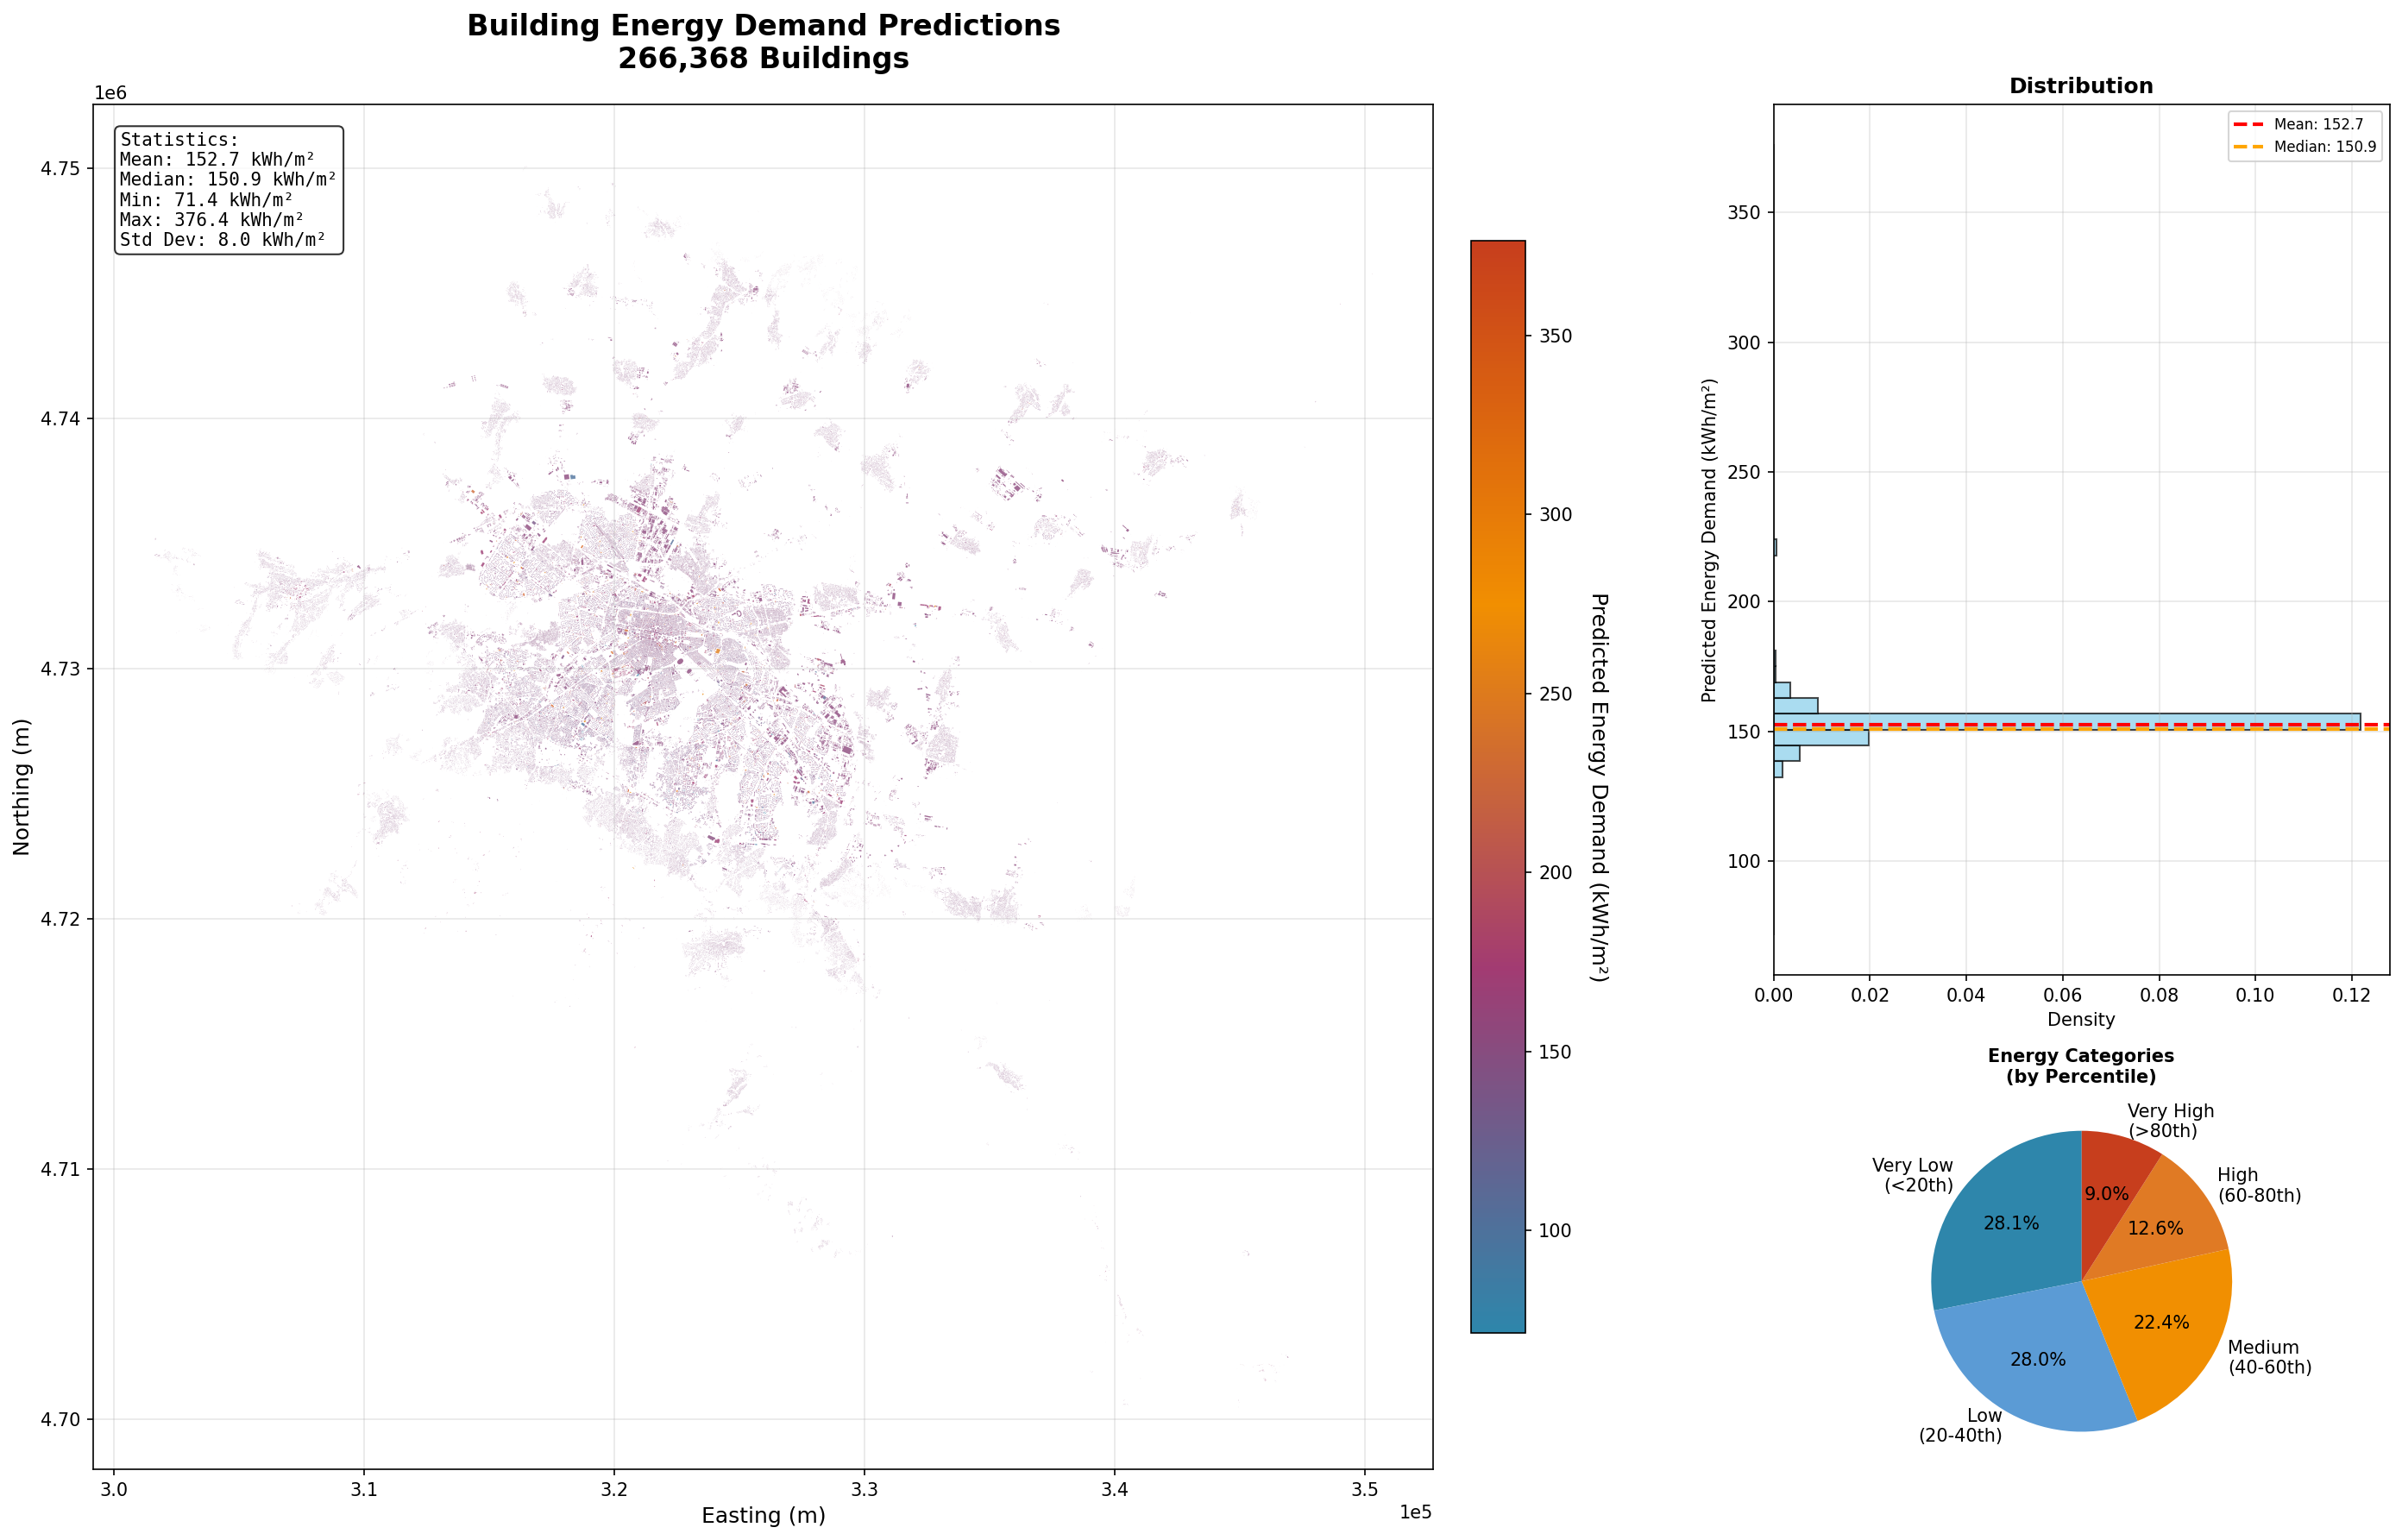


GEOGRAPHIC ANALYSIS SUMMARY
Total buildings plotted: 266,368
Prediction range: 71.4 - 376.4 kWh/m²
Mean energy demand: 152.7 kWh/m²
Median energy demand: 150.9 kWh/m²
Standard deviation: 8.0 kWh/m²
High-energy buildings (>95th percentile): 23,427

Geographic coverage (projected coordinates):
  X (Easting): 301604 to 350292 meters
  Y (Northing): 4700474 to 4750073 meters


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import geopandas as gpd
from matplotlib.patches import Patch
import seaborn as sns
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

def create_geographic_energy_heatmap(gdf_with_predictions, prediction_column='predicted_energy_demand_xgb_enhanced2',
                                   figsize=(20, 12), dpi=150, save_path=None):


    # Ensure we have valid geometry and predictions
    gdf_clean = gdf_with_predictions[
        (gdf_with_predictions.geometry.notna()) &
        (gdf_with_predictions[prediction_column].notna())
    ].copy()

    print(f"Plotting {len(gdf_clean):,} buildings with valid geometry and predictions")

    if len(gdf_clean) == 0:
        print("No valid data to plot!")
        return

    # Check coordinate system
    bounds = gdf_clean.total_bounds  # [minx, miny, maxx, maxy]
    is_projected = (abs(bounds[0]) > 180 or abs(bounds[2]) > 180 or
                   abs(bounds[1]) > 90 or abs(bounds[3]) > 90)

    if is_projected:
        print(f"Detected projected coordinate system (bounds: X={bounds[0]:.0f}-{bounds[2]:.0f}, Y={bounds[1]:.0f}-{bounds[3]:.0f})")
        coord_labels = ('Easting (m)', 'Northing (m)')
        coord_format = '{:.0f}'
    else:
        print(f"Detected geographic coordinate system (bounds: Lon={bounds[0]:.3f}-{bounds[2]:.3f}, Lat={bounds[1]:.3f}-{bounds[3]:.3f})")
        coord_labels = ('Longitude', 'Latitude')
        coord_format = '{:.3f}'

    # Get prediction statistics for color mapping
    predictions = gdf_clean[prediction_column]
    pred_min, pred_max = predictions.min(), predictions.max()
    pred_mean, pred_median = predictions.mean(), predictions.median()
    pred_std = predictions.std()

    print(f"Prediction range: {pred_min:.1f} - {pred_max:.1f} kWh/m²")
    print(f"Mean: {pred_mean:.1f}, Median: {pred_median:.1f}, Std: {pred_std:.1f}")

    # Create figure with 3 subplots (removed hotspots)
    fig = plt.figure(figsize=figsize, dpi=dpi)

    # Define custom colormap (blue to red for cold to hot)
    colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']  # Blue -> Purple -> Orange -> Red
    n_bins = 256
    custom_cmap = LinearSegmentedColormap.from_list('energy_demand', colors, N=n_bins)

    # Main heatmap (takes up most of the space)
    ax_main = plt.subplot2grid((3, 4), (0, 0), colspan=3, rowspan=3)

    # Plot the heatmap
    print("Rendering main heatmap...")

    # Use different visualization strategies based on data size
    if len(gdf_clean) > 50000:
        # For very large datasets, use smaller linewidth and markers
        gdf_clean.plot(column=prediction_column, cmap=custom_cmap,
                      linewidth=0.05, edgecolor='none',
                      ax=ax_main, alpha=0.8)
        print("Using optimized rendering for large dataset")
    elif len(gdf_clean) > 10000:
        # Medium datasets
        gdf_clean.plot(column=prediction_column, cmap=custom_cmap,
                      linewidth=0.1, edgecolor='white',
                      ax=ax_main, alpha=0.9)
        print("Using medium detail rendering")
    else:
        # Smaller datasets - full detail
        gdf_clean.plot(column=prediction_column, cmap=custom_cmap,
                      linewidth=0.2, edgecolor='white',
                      ax=ax_main, alpha=0.9)
        print("Using high detail rendering")

    # Set equal aspect ratio to prevent distortion - with robust error handling
    x_range = bounds[2] - bounds[0]
    y_range = bounds[3] - bounds[1]

    if x_range > 0 and y_range > 0 and np.isfinite(x_range) and np.isfinite(y_range):
        try:
            ax_main.set_aspect('equal', adjustable='box')
        except (ValueError, Exception) as e:
            print(f"Note: Using automatic aspect ratio")

    # Customize main map
    ax_main.set_title(f'Building Energy Demand Predictions\n{len(gdf_clean):,} Buildings',
                     fontsize=16, fontweight='bold', pad=20)
    ax_main.set_xlabel(coord_labels[0], fontsize=12)
    ax_main.set_ylabel(coord_labels[1], fontsize=12)
    ax_main.grid(True, alpha=0.3)

    # Format coordinate labels
    if is_projected:
        # For projected coordinates, use scientific notation or simplified labels
        ax_main.ticklabel_format(style='sci', axis='both', scilimits=(0,0))

    # Add colorbar
    sm = plt.cm.ScalarMappable(cmap=custom_cmap,
                              norm=plt.Normalize(vmin=pred_min, vmax=pred_max))
    sm._A = []
    cbar = plt.colorbar(sm, ax=ax_main, shrink=0.8, pad=0.02)
    cbar.set_label('Predicted Energy Demand (kWh/m²)', rotation=270, labelpad=20, fontsize=12)

    # Add statistics text box
    stats_text = f"""Statistics:
Mean: {pred_mean:.1f} kWh/m²
Median: {pred_median:.1f} kWh/m²
Min: {pred_min:.1f} kWh/m²
Max: {pred_max:.1f} kWh/m²
Std Dev: {pred_std:.1f} kWh/m²"""

    ax_main.text(0.02, 0.98, stats_text, transform=ax_main.transAxes,
                bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8),
                verticalalignment='top', fontsize=10, family='monospace')

    # Distribution histogram (right side)
    ax_hist = plt.subplot2grid((3, 4), (0, 3), rowspan=2)
    ax_hist.hist(predictions, bins=50, orientation='horizontal', color='skyblue',
                alpha=0.7, edgecolor='black', density=True)
    ax_hist.axhline(pred_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {pred_mean:.1f}')
    ax_hist.axhline(pred_median, color='orange', linestyle='--', linewidth=2, label=f'Median: {pred_median:.1f}')
    ax_hist.set_ylabel('Predicted Energy Demand (kWh/m²)')
    ax_hist.set_xlabel('Density')
    ax_hist.set_title('Distribution', fontweight='bold')
    ax_hist.legend(fontsize=8)
    ax_hist.grid(True, alpha=0.3)

    # Percentile-based categorization (bottom right)
    ax_cat = plt.subplot2grid((3, 4), (2, 3))

    # Create categories based on percentiles
    percentiles = np.percentile(predictions, [20, 40, 60, 80])  # 4 thresholds = 5 categories
    categories = ['Very Low\n(<20th)', 'Low\n(20-40th)', 'Medium\n(40-60th)',
                 'High\n(60-80th)', 'Very High\n(>80th)']

    cat_counts = []

    # First category: <= 20th percentile
    cat_counts.append((predictions <= percentiles[0]).sum())

    # Middle categories: between percentiles
    for i in range(len(percentiles) - 1):
        count = ((predictions > percentiles[i]) & (predictions <= percentiles[i+1])).sum()
        cat_counts.append(count)

    # Last category: > 80th percentile
    cat_counts.append((predictions > percentiles[-1]).sum())

    # Create pie chart
    colors_pie = ['#2E86AB', '#5B9BD5', '#F18F01', '#E07A24', '#C73E1D']
    wedges, texts, autotexts = ax_cat.pie(cat_counts, labels=categories, autopct='%1.1f%%',
                                         colors=colors_pie, startangle=90)
    ax_cat.set_title('Energy Categories\n(by Percentile)', fontweight='bold', fontsize=10)

    # Calculate hotspots for statistics (but don't plot)
    high_energy_threshold = np.percentile(predictions, 95)
    hotspots = gdf_clean[gdf_clean[prediction_column] >= high_energy_threshold]
    print(f"Identified {len(hotspots)} high-energy buildings (>95th percentile: {high_energy_threshold:.1f} kWh/m²)")

    plt.tight_layout()

    # Save if path provided
    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight', facecolor='white')
        print(f"Heatmap saved to: {save_path}")

    plt.show()

    # Print summary statistics
    print(f"\n{'='*60}")
    print("GEOGRAPHIC ANALYSIS SUMMARY")
    print(f"{'='*60}")
    print(f"Total buildings plotted: {len(gdf_clean):,}")
    print(f"Prediction range: {pred_min:.1f} - {pred_max:.1f} kWh/m²")
    print(f"Mean energy demand: {pred_mean:.1f} kWh/m²")
    print(f"Median energy demand: {pred_median:.1f} kWh/m²")
    print(f"Standard deviation: {pred_std:.1f} kWh/m²")
    print(f"High-energy buildings (>95th percentile): {len(hotspots):,}")

    # Geographic bounds
    bounds = gdf_clean.total_bounds  # [minx, miny, maxx, maxy]
    if is_projected:
        print(f"\nGeographic coverage (projected coordinates):")
        print(f"  X (Easting): {bounds[0]:.0f} to {bounds[2]:.0f} meters")
        print(f"  Y (Northing): {bounds[1]:.0f} to {bounds[3]:.0f} meters")
    else:
        print(f"\nGeographic coverage:")
        print(f"  Longitude: {bounds[0]:.4f} to {bounds[2]:.4f}")
        print(f"  Latitude: {bounds[1]:.4f} to {bounds[3]:.4f}")

    return fig

def create_detailed_choropleth(gdf_with_predictions, prediction_column='predicted_energy_demand_xgb_enhanced2',
                              classification_scheme='quantiles', n_classes=8, figsize=(24, 18)):
    """
    Create a detailed choropleth map with statistical classification

    Args:
        gdf_with_predictions: GeoDataFrame with predictions
        prediction_column: Column with predictions
        classification_scheme: 'quantiles', 'equal_interval', or 'natural_breaks'
        n_classes: Number of classes for classification
    """

    print(f"Creating detailed choropleth with {classification_scheme} classification...")

    # Clean data
    gdf_clean = gdf_with_predictions[
        (gdf_with_predictions.geometry.notna()) &
        (gdf_with_predictions[prediction_column].notna())
    ].copy()

    predictions = gdf_clean[prediction_column]

    # Create classification
    if classification_scheme == 'quantiles':
        # Equal count in each class
        bins = np.percentile(predictions, np.linspace(0, 100, n_classes + 1))
        class_labels = [f'Q{i+1}' for i in range(n_classes)]
    elif classification_scheme == 'equal_interval':
        # Equal intervals
        bins = np.linspace(predictions.min(), predictions.max(), n_classes + 1)
        class_labels = [f'C{i+1}' for i in range(n_classes)]
    else:  # natural_breaks (simplified)
        # Use quantiles as approximation for natural breaks
        bins = np.percentile(predictions, np.linspace(0, 100, n_classes + 1))
        class_labels = [f'NB{i+1}' for i in range(n_classes)]

    # Assign classes
    gdf_clean['energy_class'] = pd.cut(predictions, bins=bins, labels=class_labels, include_lowest=True)

    # Create figure
    fig, ax = plt.subplots(figsize=figsize, dpi=150)

    # Create color palette
    colors = plt.cm.Spectral_r(np.linspace(0, 1, n_classes))
    color_dict = dict(zip(class_labels, colors))

    # Plot choropleth
    for class_name in class_labels:
        class_data = gdf_clean[gdf_clean['energy_class'] == class_name]
        if len(class_data) > 0:
            class_data.plot(color=color_dict[class_name], ax=ax,
                          linewidth=0.1, edgecolor='white', alpha=0.8,
                          label=f'{class_name}: {len(class_data):,} buildings')

    # Customize plot
    ax.set_title(f'Building Energy Demand Classification\n{classification_scheme.title()} with {n_classes} Classes',
                fontsize=18, fontweight='bold', pad=20)
    ax.set_xlabel('Longitude', fontsize=14)
    ax.set_ylabel('Latitude', fontsize=14)
    ax.grid(True, alpha=0.3)

    # Add legend with statistics
    legend_text = []
    for i, class_name in enumerate(class_labels):
        class_data = gdf_clean[gdf_clean['energy_class'] == class_name]
        if len(class_data) > 0:
            min_val, max_val = bins[i], bins[i+1]
            count = len(class_data)
            pct = count / len(gdf_clean) * 100
            legend_text.append(f'{class_name}: {min_val:.0f}-{max_val:.0f} kWh/m² ({count:,} buildings, {pct:.1f}%)')

    # Create custom legend
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

    plt.tight_layout()
    plt.show()

    return fig, gdf_clean

# Usage example
# Create the comprehensive heatmap (now with 3 plots instead of 4)
heatmap_fig = create_geographic_energy_heatmap(
    gdf_data,
    prediction_column='predicted_energy_demand',
    figsize=(20, 12),  # Adjusted height since we removed one row
    dpi=150,
    save_path='energy_demand_heatmap.png'
)

Save to folder

In [ ]:
gdf_data.to_file(folder_path_shared_final + "final_predictions.geojson", driver="GeoJSON")

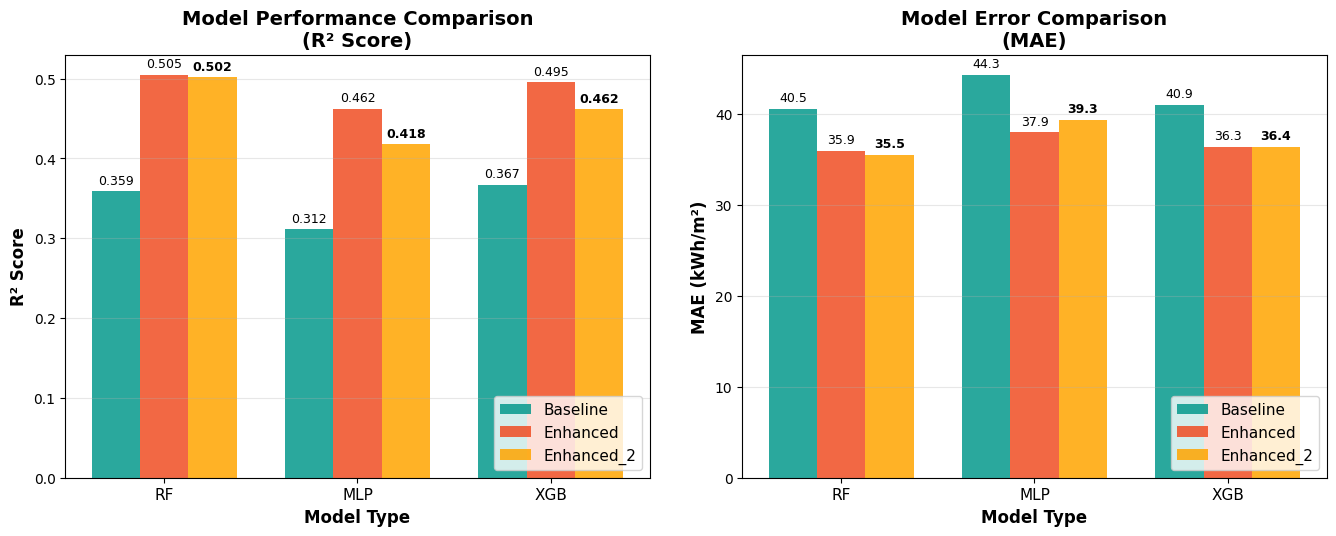

In [ ]:
def visualize_model_results_enhanced_3_features(results_df):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np

    plt.style.use('default')
    sns.set_palette("husl")

    fig = plt.figure(figsize=(14, 6))

    BASELINE_COLOR = '#05998c'
    ENHANCED_COLOR = '#f04d23'
    ENHANCED_2_COLOR = '#FFA500'

    results_no_lstm = results_df[results_df['Model'] != 'LSTM'].copy()
    models = ['RF', 'MLP', 'XGB']

    # ==== 1. R² ====
    ax1 = plt.subplot(1, 2, 1)

    baseline_data = results_no_lstm[results_no_lstm['Features'] == 'Baseline'].set_index('Model')['R²']
    enhanced_data = results_no_lstm[results_no_lstm['Features'] == 'Enhanced'].set_index('Model')['R²']
    enhanced_2_data = results_no_lstm[results_no_lstm['Features'] == 'Enhanced_2'].set_index('Model')['R²']

    baseline_data = baseline_data.reindex(models, fill_value=0)
    enhanced_data = enhanced_data.reindex(models, fill_value=0)
    enhanced_2_data = enhanced_2_data.reindex(models, fill_value=0)

    x = np.arange(len(models))
    width = 0.25

    bars1 = ax1.bar(x - width, baseline_data.values, width,
                    label='Baseline', alpha=0.85, color=BASELINE_COLOR)
    bars2 = ax1.bar(x, enhanced_data.values, width,
                    label='Enhanced', alpha=0.85, color=ENHANCED_COLOR)
    bars3 = ax1.bar(x + width, enhanced_2_data.values, width,
                    label='Enhanced_2', alpha=0.85, color=ENHANCED_2_COLOR)

    ax1.set_xlabel('Model Type', fontsize=12, fontweight='bold')
    ax1.set_ylabel('R² Score', fontsize=12, fontweight='bold')
    ax1.set_title('Model Performance Comparison\n(R² Score)', fontsize=14, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(models, fontsize=11)
    ax1.legend(fontsize=11, loc='lower right')  # <-- here
    ax1.grid(axis='y', alpha=0.3)

    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            h = bar.get_height()
            if h > 0:
                ax1.text(bar.get_x() + bar.get_width()/2., h + 0.005, f'{h:.3f}',
                         ha='center', va='bottom', fontsize=9,
                         fontweight='bold' if bars == bars3 else 'normal')

    # ==== 2. MAE ====
    ax2 = plt.subplot(1, 2, 2)

    baseline_mae = results_no_lstm[results_no_lstm['Features'] == 'Baseline'].set_index('Model')['MAE']
    enhanced_mae = results_no_lstm[results_no_lstm['Features'] == 'Enhanced'].set_index('Model')['MAE']
    enhanced_2_mae = results_no_lstm[results_no_lstm['Features'] == 'Enhanced_2'].set_index('Model')['MAE']

    baseline_mae = baseline_mae.reindex(models, fill_value=0)
    enhanced_mae = enhanced_mae.reindex(models, fill_value=0)
    enhanced_2_mae = enhanced_2_mae.reindex(models, fill_value=0)

    bars4 = ax2.bar(x - width, baseline_mae.values, width,
                    label='Baseline', alpha=0.85, color=BASELINE_COLOR)
    bars5 = ax2.bar(x, enhanced_mae.values, width,
                    label='Enhanced', alpha=0.85, color=ENHANCED_COLOR)
    bars6 = ax2.bar(x + width, enhanced_2_mae.values, width,
                    label='Enhanced_2', alpha=0.85, color=ENHANCED_2_COLOR)

    ax2.set_xlabel('Model Type', fontsize=12, fontweight='bold')
    ax2.set_ylabel('MAE (kWh/m²)', fontsize=12, fontweight='bold')
    ax2.set_title('Model Error Comparison\n(MAE)', fontsize=14, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(models, fontsize=11)
    ax2.legend(fontsize=11, loc='lower right')  # <-- and here
    ax2.grid(axis='y', alpha=0.3)

    for bars in [bars4, bars5, bars6]:
        for bar in bars:
            h = bar.get_height()
            if h > 0:
                ax2.text(bar.get_x() + bar.get_width()/2., h + 0.5, f'{h:.1f}',
                         ha='center', va='bottom', fontsize=9,
                         fontweight='bold' if bars == bars6 else 'normal')

    plt.tight_layout(pad=3.0)
    plt.show()
    return fig

fig = visualize_model_results_enhanced_3_features(tuned_results)




